# DIGI405 Text Analysis Project Notebook

[0.2.5 - 2025-10-08](https://github.com/polsci/DIGI405-assignments/blob/main/CHANGELOG.md) - optional functionality to run inference on augmented data or data from a CSV  
[0.2.3 - 2025-09-15](https://github.com/polsci/DIGI405-assignments/blob/main/CHANGELOG.md) - metric ordering    
[0.2.2 - 2025-09-08](https://github.com/polsci/DIGI405-assignments/blob/main/CHANGELOG.md) - quality of life improvements, probability labels    
[0.2.1 - 2025-08-19](https://github.com/polsci/DIGI405-assignments/blob/main/CHANGELOG.md) - ensure filtering / grid search handled as expected   
Note: Search notebook for 0.2.1/0.2.2/0.2.3/0.2.5 to find changes if you want to apply to your existing notebook.

## Introduction

You should use this notebook as a starting point for your DIGI405 project. It provides code to select your dataset, and run a complete text classification pipeline with [textplumber](https://geoffford.nz/textplumber/), a package that provides an easy to use interface to methods covered in this course.

### Submission package and folder structure

This notebook is intended to be distributed inside a zip archive that is extracted with Python. When the archive is unpacked, keep the top-level folder `FINAL-PROJECT/` intact.

The notebook itself should remain inside `FINAL-PROJECT/python/*.ipynb`. Do not move the notebook to a different folder before running it.

This matters because the notebook uses relative paths and expects enough headroom to create sibling folders such as `data/`, `figs/`, and `results/` under `FINAL-PROJECT/`. If the folder structure is preserved, no extra path instructions should be needed for the user.

After the first run has created the working folders, the notebook can also be run manually in the usual way, provided it remains inside the same `FINAL-PROJECT/python/` location.

**Name:**            David Ewing  
**Student ID:**      82171165  
**Project option:** Sentiment  


## Problem Statement

    "This project evaluates the quality of sentiment labels applied to the Cardiff NLP [tweet_eval sentiment dataset](https://huggingface.co/datasets/cardiffnlp/tweet_eval/viewer/sentiment) -- a sample of approximagely 45,000 tweets labelled:  *negative*, *neutral*, or *positive*.\n",

**My central question:**

 - How reliably is a text classifier able to reproduce the human-assigned sentiment labels?
 - What does a text classifier's performance tell us about the quality and consistency of the labels?**

**Sub-questions:**
1. What is the nature of problems exist with the labelling of tweets?  
2. What types of tweet are systematically hard to classify? 
3. Which feature(s) are most informative for distinguishing sentiment classes?

### Evaluation metrics

The dataset is dramatically imbalanced. Because the dataset is imbalanced (neutral ≈ 45% of training data), macro avg F1 will be used as the primary evaluation metric:
  - macro avg F1 weights each class equally regardless of size, 
  - Precision and recall are reported per-class to show us where misclassifications occur, and 
  - Accuracy is not used as the primary metric.

## Model plan

We will run the pipeline  twice, in a loop, swapping which line is commented out: 
- logistic regression as a baseline, and 
- decision tree to see what rules emerge from the data.

Features we are to test, (building from simple to more complex):
- unigram token counts (small vocab to start)
- unigram tokens, TF-IDF weighted (larger vocab)
- bigrams
- VADER sentiment lexicon counts — likely the most relevant given the task
- text statistics (tweet length, punctuation)
- POS tag sequences

We will also try running as a binary task (negative vs positive only) to check whether neutral is where most of the difficulty sits.

### Notebook structure

Sections 1-4 provide code you should modify or extend. In your report, you can refer to code sections by their section number, eg 2.1.

## 1. Setup

You must select the Python 3.12 kernel to run the code in this notebook. 

In [1]:
import subprocess
import sys
import asyncio

# Use selector policy on Windows to avoid nbconvert/zmq event-loop hangs.
if sys.platform.startswith("win"):
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

required_packages = {
    'datasets':     'datasets',
    'sklearn':      'scikit-learn',
    'textplumber':  'textplumber',
    'imblearn':     'imbalanced-learn',
    'nlpaug':       'nlpaug',
    'spacy':        'spacy',
    'numpy':        'numpy',
    'PIL':          'pillow',
}

missing = []
for import_name, package_name in required_packages.items():
    try:
        __import__(import_name)
        print(f"OK : {package_name}")
    except ModuleNotFoundError:
        print(f"INSTALL : {package_name}")
        missing.append(package_name)

if missing:
    print(f"\nInstalling {len(missing)} missing package(s)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    print("OK : Installation complete\n")
else:
    print("\nOK : All dependencies available\n")

OK : datasets


OK : scikit-learn
OK : textplumber


OK : imbalanced-learn


OK : nlpaug


OK : spacy
OK : numpy
OK : pillow

OK : All dependencies available



In [2]:
from datasets import load_dataset, load_from_disk, ClassLabel, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import spacy
import pickle
import shutil
import time
import os
from pathlib import Path
import nlpaug.augmenter.char as nac
from PIL import Image as PILImage

from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import confusion_matrix, classification_report

from textplumber.core import *
from textplumber.clean import *
from textplumber.preprocess import *
from textplumber.tokens import *
from textplumber.pos import *
from textplumber.embeddings import *
from textplumber.report import *
from textplumber.store import *
from textplumber.lexicons import *
from textplumber.textstats import *

from imblearn.under_sampling import RandomUnderSampler
from IPython.display import Image, display

import matplotlib.pyplot as plt
plt.switch_backend('Agg')

import warnings
warnings.filterwarnings("ignore", message="Your stop_words may be inconsistent with your preprocessing")

In [3]:
# Ensure spaCy model is available for textplumber pipelines (JupyterHub-safe, fail-fast)

def ensure_spacy_model(model_name='en_core_web_sm', timeout_seconds=180):
    try:
        spacy.load(model_name)
        print(f'OK : {model_name} already available')
        return True
    except OSError:
        print(f'INSTALL : {model_name} (using current kernel Python)')

    try:
        subprocess.run(
            [sys.executable, '-m', 'spacy', 'download', model_name],
            check=True,
            timeout=timeout_seconds,
        )
        spacy.load(model_name)
        print(f'OK : {model_name} installed')
        return True
    except subprocess.TimeoutExpired:
        print(f'FAIL : Timed out after {timeout_seconds}s while installing {model_name}')
        return False
    except Exception as exc:
        print(f'FAIL : Could not install {model_name}: {exc}')
        return False


# SPACY_MODEL_OK = ensure_spacy_model()

These settings control the display of Pandas dataframes in the notebook.

In [4]:
pd.set_option('display.max_columns', None) # show all columns
pd.set_option('display.max_colwidth', 500) # increase this to see more text in the dataframe

Get word lists: 
* The stop word list is from NLTK.   
* All of the word lists (including the stop word list) can be used to extract lexicon count features to extract features based on a set of words.

In [5]:
stop_words         = get_stop_words()
stop_words_lexicon = {'stop_words': stop_words}
empath_lexicons    = get_empath_lexicons()
vader_lexicons     = get_sentiment_lexicons()

def _tok(ngram, max_f, feature_store, stop_words):
    return Pipeline([('vec', TokensVectorizer(
        feature_store=feature_store, vectorizer_type='count',
        max_features=max_f, lowercase=True, remove_punctuation=True,
        stop_words=stop_words, ngram_range=ngram))])

def setup_feature_configs(feature_store, stop_words, vader_lexicons):
    return {
        'unigrams':   FeatureUnion([('tokens', _tok((1, 1), 200, feature_store, stop_words))]),
        'bigrams':    FeatureUnion([('tokens', _tok((2, 2), 200, feature_store, stop_words))]),
        'uni+pos':    FeatureUnion([('tokens', _tok((1, 1), 100, feature_store, stop_words)),
                                    ('pos',    Pipeline([('vec', POSVectorizer(feature_store=feature_store)),
                                                        ('scl', StandardScaler(with_mean=False))]))]),
        'textstats':  FeatureUnion([('ts',     Pipeline([('vec', TextstatsTransformer(feature_store=feature_store)),
                                                        ('scl', StandardScaler(with_mean=False))]))]),
        'lexicon':    FeatureUnion([('lex',    Pipeline([('vec', LexiconCountVectorizer(feature_store=feature_store, lexicons=vader_lexicons)),
                                                        ('scl', StandardScaler(with_mean=False))]))]),
        'embeddings': FeatureUnion([('emb',    Model2VecEmbedder(feature_store=feature_store))]),
    }

def setup_classifiers():
    return [
        ('LR', LogisticRegression(max_iter=5000, random_state=82171165)),
        ('DT', DecisionTreeClassifier(max_depth=3, random_state=82171165)),
    ]

def _assert_artifact(path, label):
    path = Path(path)
    if not path.exists():
        raise RuntimeError(f"Expected {label} not found on disk: {path}")
    size = path.stat().st_size
    if size == 0:
        raise RuntimeError(f"Expected {label} is empty on disk: {path}")
    status = f"ok: {label}"
    print(f"    {status:<40} -> {path.name} ({size:,} bytes)")

def _format_report_df(report_dict):
    rpt_df = pd.DataFrame(report_dict).T.copy()
    numeric_cols = rpt_df.select_dtypes(include=[np.number]).columns
    rpt_df.loc[:, numeric_cols] = rpt_df.loc[:, numeric_cols].round(3)
    if 'support' in rpt_df.columns:
        rpt_df['support'] = rpt_df['support'].round().astype(int)
    return rpt_df

def save_results(results_dict, run_name):
    path = Path(f'../results/runs/{run_name}.pkl')
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'wb') as f:
        pickle.dump(results_dict, f)
    _assert_artifact(path, f"run cache {run_name}")
    return path

def load_results(run_name):
    path = Path(f'../results/runs/{run_name}.pkl')
    if path.exists():
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None

def train_and_evaluate_model(feat_name, feat_union, clf_name, clf, X_train, y_train, X_test, y_test,
                             target_classes, target_names, feature_store, results_dict, is_binary=False, store_pipeline=False, silent=True):
    pipe = Pipeline([
        ('cleaner',    TextCleaner(strip_whitespace=True)),
        ('spacy',      SpacyPreprocessor(feature_store=feature_store)),
        ('features',   feat_union),
        ('classifier', clone(clf) if is_binary else clf),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rpt = classification_report(
        y_test, y_pred,
        labels=target_classes, target_names=target_names,
        digits=3, zero_division=0, output_dict=True)

    results_dict[(feat_name, clf_name)] = {
        'macro_f1': rpt['macro avg']['f1-score'],
        'report':   rpt,
        'y_pred':   y_pred,
    }

    if store_pipeline:
        results_dict[(feat_name, clf_name)]['pipeline'] = pipe

    if not silent:
        if is_binary:
            print(f'\n  [binary] {feat_name}  x  {clf_name}')
        else:
            print(f'\n  {feat_name}  x  {clf_name}')
        print(classification_report(
            y_test, y_pred,
            labels=target_classes, target_names=target_names,
            digits=3, zero_division=0))
        plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

def save_run(run_num, title, results_dict, clf_name, y_test, classes, names):
    print(f"\n{title}")
    for feat_name in feat_configs.keys():
        rpt      = results_dict[(feat_name, clf_name)]['report']
        y_pred   = results_dict[(feat_name, clf_name)]['y_pred']
        stem     = f'cm_run{run_num}_{feat_name}_{clf_name}'
        csv_path = FIGS_DIR / f'{stem}.csv'
        fig_path = FIGS_DIR / f'{stem}.png'

        rpt_df = _format_report_df(rpt)
        rpt_df.to_csv(csv_path)
        _assert_artifact(csv_path, f"report table {stem}")

        with plt.ioff():
            plot_confusion_matrix(y_test, y_pred, classes, names, renderer='img')
            fig = plt.gcf()
            ax = plt.gca()
            fig.set_size_inches(6.2, 5.4)
            ax.tick_params(labelsize=11)

            ytick_labels = []
            for tick in ax.get_yticklabels():
                label = tick.get_text()
                if ' (Total:' in label:
                    label = label.split(' (Total:')[0]
                ytick_labels.append(label)
            ax.set_yticks(ax.get_yticks())
            ax.set_yticklabels(ytick_labels, rotation=0, va='center', ha='right')

            xtick_labels = []
            for tick in ax.get_xticklabels():
                label = tick.get_text()
                if ' (Total:' in label:
                    label = label.split(' (Total:')[0]
                xtick_labels.append(label)
            ax.set_xticks(ax.get_xticks())
            ax.set_xticklabels(xtick_labels, rotation=0, ha='center')

            ax.xaxis.label.set_size(12)
            ax.yaxis.label.set_size(12)
            ax.xaxis.labelpad = 10
            ax.yaxis.labelpad = 12
            ax.title.set_size(12)

            for txt in ax.texts:
                txt.set_fontsize(11)

            for txt in fig.texts:
                if 'Note:' in txt.get_text():
                    txt.set_fontsize(9)
                    txt.set_ha('left')
                    txt.set_position((0.12, 0.02))

            fig.subplots_adjust(left=0.32, bottom=0.20)
            plt.savefig(fig_path, bbox_inches='tight', dpi=150)
            plt.close('all')
        _assert_artifact(fig_path, f"confusion matrix {stem}")

        status = f"saved: {feat_name}_{clf_name}"
        print(f"    {status:<40} -> {stem}")

    best_key, best_score = max(((k, results_dict[k]['macro_f1']) for k in results_dict), key=lambda x: x[1])
    best_label = f"best: {best_key[0]} x {best_key[1]}"
    print(f"    {best_label:<40} -> macro F1 = {best_score:.3f}")
    return best_key, best_score

## 2. Load and inspect data

### 2.0 Parquet split cache

Builds reproducible, balanced train/test splits from the raw CSVs and saves them as parquet files. If the files already exist the cell is a no-op. Both the 3-class task (negative / neutral / positive) and the binary task (negative / positive) are prepared here so downstream cells can load them without repeating the undersampling.

In [6]:
CLEANUP_BEFORE_RUN = True

if CLEANUP_BEFORE_RUN:
    shutil.rmtree(Path('../results/runs'), ignore_errors=True)
    shutil.rmtree(Path('../figs'), ignore_errors=True)
    print("CLEANUP : results/runs and figs")

CLEANUP : results/runs and figs


In [7]:
DATA_DIR         = Path('../data').resolve()
RESULTS_DATA_DIR = Path('../results/data').resolve()
FIGS_DIR         = Path('../figs').resolve()

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
print(f"OK : {DATA_DIR}")
print(f"OK : {RESULTS_DATA_DIR}")
print(f"OK : {FIGS_DIR}")

TRAIN_CSV = DATA_DIR / 'tweets_train.csv'
VAL_CSV   = DATA_DIR / 'tweets_validation.csv'

if not TRAIN_CSV.exists() or not VAL_CSV.exists():
    print("Downloading from HuggingFace...")
    dataset_hf = load_dataset('cardiffnlp/tweet_eval', 'sentiment')
    train_df = dataset_hf['train'].to_pandas()
    val_df   = dataset_hf['validation'].to_pandas()
    train_df.to_csv(TRAIN_CSV, index=False)
    val_df.to_csv(VAL_CSV, index=False)
    print(f"OK : Downloaded and saved to {DATA_DIR}")
else:
    print(f"OK : Using existing files from {DATA_DIR}")

PARQUET_3CLASS = RESULTS_DATA_DIR / 'splits_3class.parquet'
PARQUET_BINARY = RESULTS_DATA_DIR / 'splits_binary.parquet'

def _build_parquet(classes, out_path):
    train_df = pd.read_csv(TRAIN_CSV)
    val_df   = pd.read_csv(VAL_CSV)

    mask_tr = train_df['label'].isin(classes)
    mask_te = val_df['label'].isin(classes)

    X_tr = train_df.loc[mask_tr, 'text'].to_numpy().reshape(-1, 1)
    y_tr = train_df.loc[mask_tr, 'label'].to_numpy()
    X_tr, y_tr = RandomUnderSampler(random_state=82171165).fit_resample(X_tr, y_tr)
    X_tr = X_tr.reshape(-1)

    X_te = val_df.loc[mask_te, 'text'].to_numpy()
    y_te = val_df.loc[mask_te, 'label'].to_numpy()

    combined = pd.concat([
        pd.DataFrame({'split': 'train', 'text': X_tr, 'label': y_tr}),
        pd.DataFrame({'split': 'test',  'text': X_te, 'label': y_te}),
    ], ignore_index=True)
    combined.to_parquet(out_path, index=False)
    print(f'OK : {out_path.name} (train n={len(X_tr):,}, test n={len(X_te):,})')

for label, classes, path in [
    ('3-class (neg/neu/pos)', [0, 1, 2], PARQUET_3CLASS),
    ('binary  (neg/pos)',     [0, 2],    PARQUET_BINARY),
]:
    if path.exists():
        print(f"OK : {path.name} already exists")
    else:
        print(f"Building {label}...")
        _build_parquet(classes, path)

OK : D:\github\DIGI405-final-project\data
OK : D:\github\DIGI405-final-project\results\data
OK : D:\github\DIGI405-final-project\figs
OK : Using existing files from D:\github\DIGI405-final-project\data
OK : splits_3class.parquet already exists
OK : splits_binary.parquet already exists


### 2.1 Choose a dataset and preview the labels

Below you can select a dataset for the assignment. The options are `sentiment`, `essay` and `genre`. Change the value of `dataset_option` below. The datasets available on Huggingface.co will be downloaded automatically and a link provided to the dataset card with more information. The `genre` dataset was distributed with this notebook.   

Note:  The `movie_reviews` dataset is being used to demonstrate the notebook and is not one of your options for the assignment.  

In [8]:
# Choose 'essay', 'sentiment', or 'genre' ('movie_reviews' is just for testing/demonstration)
dataset_option = 'sentiment'

if dataset_option == 'movie_reviews':
	dataset_name = 'polsci/sentiment-polarity-dataset-v2.0'
	dataset_dir = None
	target_labels = ['neg', 'pos']
	text_column = 'text'
	label_column = 'label'
	train_split_name = 'train'
	test_split_name = 'train'
	print('The movie_reviews is to demonstrate the notebook and is not an assignment option.')
elif dataset_option == 'sentiment':
	dataset_name = 'cardiffnlp/tweet_eval'
	dataset_dir = 'sentiment'
	target_labels = ['negative', 'neutral', 'positive']
	text_column = 'text'
	label_column = 'label'
	train_split_name = 'train'
	test_split_name = 'validation'
	print('You selected the sentiment dataset. Read more about this at https://huggingface.co/datasets/cardiffnlp/tweet_eval')
elif dataset_option == 'essay':
	dataset_name = 'polsci/ghostbuster-essay-cleaned'
	dataset_dir = None
	target_labels = ['claude', 'gpt', 'human']
	text_column = 'text'
	label_column = 'label'
	train_split_name = 'train'
	test_split_name = 'test'
	print('You selected the essay dataset. Read more about this at https://huggingface.co/datasets/polsci/ghostbuster-essay-cleaned')
elif dataset_option == 'genre':
    dataset_name = 'genre'
    dataset_type = 'json'
	# Note: Quality of life improvement for version 0.2.2
    dataset_dir = '/srv/source-data/genre_dataset.json' # if you are running this locally change to the path on your machine
    target_labels = ['Fiction', 'Letter', 'Notice', 'Obituary', 'Poetry or verse', 'Recipe', 'Review']
    text_column = 'text'
    label_column = 'label'
    train_split_name = 'train'
    test_split_name = 'test'
    print('You selected the genre dataset.')
else:
	print('Try again! That was not an option!')

You selected the sentiment dataset. Read more about this at https://huggingface.co/datasets/cardiffnlp/tweet_eval


#### Important notes about specific datasets:

* Make sure you go to the relevant Huggingface page to read more about the [essay](https://huggingface.co/datasets/polsci/ghostbuster-essay-cleaned) and [sentiment](https://huggingface.co/datasets/cardiffnlp/tweet_eval/viewer/sentiment) datasets. Note the sentiment dataset is one subset of the larger 'tweet_eval' dataset.  
* For the *sentiment* dataset, it is challenging to get good accuracy with three classes. If you like you can remove the `neutral` class. There is a cell below that does this for you - don't change the cell above.
* For the *essay* dataset, there are differences in punctuation between classes. You should use `character_replacements = {"’": "'", '“': '"', '”': '"',}` in the `TextCleaner` component in your pipeline to make sure you are not overfitting to a quirk of the data.

This loads the dataset. 

In [9]:
DATASET_CACHE = DATA_DIR / 'tweet_eval_raw'

if dataset_option == 'genre':
    if DATASET_CACHE.exists():
        print(f"\nLoading cached genre dataset from {DATASET_CACHE}...")
        dataset = load_from_disk(str(DATASET_CACHE))
        print("OK : Dataset loaded from cache\n")
    else:
        print(f"\nLoading genre dataset from {dataset_dir}...")
        dataset = load_dataset(dataset_type, data_files=dataset_dir)
        train_dataset = dataset['train'].filter(lambda example: example['split'] == 'train')
        test_dataset = dataset['train'].filter(lambda example: example['split'] == 'test')
        dataset = DatasetDict({
            'train': train_dataset,
            'test': test_dataset
        })
        print(f"Caching dataset to {DATASET_CACHE}...")
        dataset.save_to_disk(str(DATASET_CACHE))
        print("OK : Genre dataset cached\n")
else:
    if DATASET_CACHE.exists():
        print(f"\nLoading cached dataset from {DATASET_CACHE}...")
        dataset = load_from_disk(str(DATASET_CACHE))
        print("OK : Dataset loaded from cache\n")
    else:
        print(f"\nDownloading {dataset_option} dataset from HuggingFace...")
        dataset = load_dataset(dataset_name, data_dir=dataset_dir)
        print(f"Caching dataset to {DATASET_CACHE}...")
        dataset.save_to_disk(str(DATASET_CACHE))
        print("OK : Dataset downloaded and cached\n")


Loading cached dataset from D:\github\DIGI405-final-project\data\tweet_eval_raw...
OK : Dataset loaded from cache



In [10]:
# dataset loaded and cached above

This cell will show you information on the dataset fields and the splits.

In [11]:
preview_dataset(dataset)

Here is the breakdown of the composition of labels in each data-set split.

In [12]:
# casting label column to ClassLabel if not already
cast_column_to_label(dataset, label_column)
label_names = get_label_names(dataset, label_column)

dfs = {}
for split in dataset.keys():
    dfs[split] = dataset[split].to_pandas()
    dfs[split].insert(1, 'label_name', dfs[split][label_column].apply(lambda x: dataset[split].features[label_column].int2str(x)))
    print('Labels for {}:'.format(split))
    preview_label_counts(dfs[split], label_column, label_names)

Column 'label' is already a ClassLabel.


Labels for train:


,label_name,count
label,,
0,negative,7093
1,neutral,20673
2,positive,17849


Labels for validation:


,label_name,count
label,,
0,negative,312
1,neutral,869
2,positive,819


Labels for test:


,label_name,count
label,,
0,negative,3972
1,neutral,5937
2,positive,2375


### 2.2 Configure the labels (optional)

* You can override the default labels for the data-set here to make the task more or less challenging. High accuracy does not guarantee a high grade. 
* See the assignment instructions and the dataset card or corresponding paper for explanations of the data.  
* Read the comments below and uncomment the relevant lines for your data-set if and amend the label names if needed.
* Remember, this is optional.

In [13]:
# for the movie reviews dataset (this is just for testing/demonstration) - there are 2 labels and that is it!

# for the sentiment dataset - there are 3 labels - you can make the task simpler as a binary classification problem using one of these options:
#target_labels = ['negative', 'neutral']
#target_labels = ['negative', 'positive']
#target_labels = ['neutral', 'positive']

# for the essay dataset - there are 7 labels - you can make the task simpler as a binary classification problem using one of these options:
#target_labels = ['claude', 'gpt']
#target_labels = ['human', 'gpt'] 
#target_labels = ['human', 'claude']

# for the genre dataset - there are 7 labels - you can turn the task into one or more binary classification problems using options such as:
#target_labels = ['Letter', 'Notice']
#target_labels = ['Letter', 'Fiction']
#target_labels = ['Review', 'Fiction']
#target_labels = ['Notice', 'Obituary']

print(target_labels)

['negative', 'neutral', 'positive']


### 2.3 Prepare the train and test splits

* This cell handles the train-test split for you.
* Some of the data-sets are unbalanced. This cell will balance the training data using under-sampling.

In [14]:
target_classes = [label_names.index(name) for name in target_labels]
target_names = [label_names[i] for i in target_classes]

if train_split_name == test_split_name:
    X = dataset[train_split_name].to_pandas()
    X.insert(1, 'label_name', dfs[train_split_name][label_column].apply(lambda x: dataset[train_split_name].features[label_column].int2str(x)))
    y = np.array(dataset[train_split_name][label_column])

    mask = np.isin(y, target_classes)
    X = X.loc[mask]
    y = y[mask]

    # creating df splits with original data first  - so can look at the train data if needed
    dfs['train'], dfs['test'], y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=82171165, stratify=y)

    # we're just using the text for features
    X_train = np.array(dfs['train'][text_column])
    X_test = np.array(dfs['test'][text_column])
else:
    X_train = np.array(dataset[train_split_name][text_column])
    y_train = np.array(dataset[train_split_name][label_column])
    X_test = np.array(dataset[test_split_name][text_column])
    y_test = np.array(dataset[test_split_name][label_column])

    mask = np.isin(y_train, target_classes)
    mask_test = np.isin(y_test, target_classes)

    X_train = X_train[mask]
    y_train = y_train[mask]
    X_test = X_test[mask_test]
    y_test = y_test[mask_test]

# this cell undersamples all but the minority class to balance the training data
X_train = X_train.reshape(-1, 1)
X_train, y_train = RandomUnderSampler(random_state=82171165).fit_resample(X_train, y_train)
X_train = X_train.reshape(-1)

preview_splits(X_train, y_train, X_test, y_test, target_classes = target_classes, target_names = target_names)

Train: 21279 samples, 3 classes


,label_name,count
0,,
0,negative,7093
1,neutral,7093
2,positive,7093


Test: 2000 samples, 3 classes


,label_name,count
0,,
1,neutral,869
2,positive,819
0,negative,312


### 2.4 Preview the texts

Time to get to know your data. We will only preview the train split.

In [15]:
y_train_names = map(lambda x: label_names[x], y_train)
# Note: Version 0.2.1 corrects display of the dataframe to ensure filtering by the selected labels 
display(dfs['train'][dfs['train']['label_name'].isin(y_train_names)].sample(10))

,text,label_name,label
8740,@user C\u2019mon guys fix this please\u002c i dont want this to end up how Diablo III did....... :.(,negative,0
29668,Tracy McGrady arrived in China on Wed after signing with Qingdao Eagles. His arrival at the airport was crazy -,positive,2
18552,@user When are you really landing in NZ? Ash said morning? Then you said Saturday night? And then you said mid day tomorrow? :L x,neutral,1
728,Floyd Mayweather may be good at dodging punches but Ronda Rousey would beat the shit out of him.,neutral,1
33701,@user she\u2019s got anne curtis\u002c toni gonzaga\u002c dat guy who looks like bruno mars from last sunday\u002c idk his name lol n 4 others idk them :D,neutral,1
38569,6 minutes from first Saturday broadcast of the season. Mary Jo Heath and Ira Siff ready to go! @user,positive,2
38636,Mark Martin by far the most unluckiest Nascar driver of all time\u002c 2nd 5 times in points & the heartbreaking 07 Daytona 500.,negative,0
8750,@user I think it has to do with fan attacking Dean Ambrose Saturday night,neutral,1
31752,"""So sad to see the Broadwalk in Atlantic City destroyed, we were only there back in April - hope they can rebuild it #AtlanticCity #Sandy""",negative,0
15079,@user You beat them 5-1 in the San Siro but Terry Henrys 3rd goal is world class. #NeverMindPires!,positive,2


Enter the index (the number in the first column) as `selected_index` to see the row. The `limit` value controls how much of the text you see. Set a higher limit to see more of the text or set it to 0 to see all of the text.

In [16]:
# We can display the full text of a selected article by dataframe index
selected_index = 10

preview_row_text(dfs['train'], selected_index, text_column = text_column, limit=400) # change limit to see more of the text if needed

,Value
Attribute,
label_name,neutral
label,1


text:
@user Well said on HMW. Can you now address why Texans fans file out of the
stadium midway through the 4th qtr of every game?


### 2.5 Dataset class distribution

Class counts at each stage of data preparation: raw HF splits - filtered to target labels - after undersampling. The validation split is used as the held-out test set throughout.

In [17]:
_lmap = {0: 'negative', 1: 'neutral', 2: 'positive'}

train_raw = pd.read_csv(DATA_DIR / 'tweets_train.csv')
val_raw   = pd.read_csv(DATA_DIR / 'tweets_validation.csv')

stages = [
    ('Train — raw HF',                train_raw,                                         None),
    ('Train — filtered to target',    train_raw[train_raw['label'].isin(target_classes)], None),
    ('Train — after undersampling',   None,                                               (y_train, target_classes)),
    ('Test  — validation (filtered)', val_raw[val_raw['label'].isin(target_classes)],    None),
]

col_w = max(len(n) for n, _, _ in stages) + 2
hdr   = f"{'Stage':{col_w}}  {'negative':>10}  {'neutral':>10}  {'positive':>10}  {'Total':>10}"
sep   = '-' * len(hdr)
print(hdr)
print(sep)

for name, df, arr_info in stages:
    if arr_info is not None:
        y_arr, classes = arr_info
        counts = {c: int((y_arr == c).sum()) for c in classes}
    else:
        counts = df['label'].value_counts().to_dict()
    neg = counts.get(0, 0)
    neu = counts.get(1, 0)
    pos = counts.get(2, 0)
    tot = neg + neu + pos
    print(f"{name:{col_w}}  {neg:>10,}  {neu:>10,}  {pos:>10,}  {tot:>10,}")

print(sep)

Stage                              negative     neutral    positive       Total
-------------------------------------------------------------------------------
Train — raw HF                        7,093      20,673      17,849      45,615
Train — filtered to target            7,093      20,673      17,849      45,615
Train — after undersampling           7,093       7,093       7,093      21,279
Test  — validation (filtered)           312         869         819       2,000
-------------------------------------------------------------------------------


## 3. Create a classification pipeline and train a model

Create a Sci-kit Learn pipeline to preprocess the texts and train a classification model. The pipeline components will be added in through the notebook. There are a number of pipeline components you can access through the `textplumber` package. You will have an opportunity to learn about this in labs, but documentation is [available here](https://geoffford.nz/textplumber).

To speed up preprocessing some of the pipeline components store the preprocessed data in a cache to avoid recomputing them. Run this as is - it will create an SQLite file with the name of your dataset option in the directory of the notebook. This will speed up some repeated processing (e.g. tokenization with Spacy).

In [18]:
feature_store = TextFeatureStore(f'assignment-{dataset_option}.sqlite')

The pipeline below includes a number of different components. Most are commented out on the first run of the notebook. There are lots of options for each component. You will need to look at the documentation and examples in labs to learn about these. These components can extract different kinds of features, any of which can be applied to build a model. The feature types include:

* Token features  
* Bigram features  
* Parts of speech features
* Lexicon-based features  
* Document-level statistics  
* Text embeddings


In [19]:
pipeline = Pipeline([
	('cleaner', TextCleaner(strip_whitespace=True)), # for the essay dataset you should use character_replacements = {"’": "'", '“': '"', '”': '"',}
	('spacy', SpacyPreprocessor(feature_store=feature_store)),
	('features', FeatureUnion([
		('tokens', # token features - these can be single tokens or ngrams of tokens using TokensVectorizer - see textplumber documentation for examples
			Pipeline([
				('spacy_token_vectorizer', TokensVectorizer(feature_store = feature_store, vectorizer_type='count', max_features=100, lowercase = True, remove_punctuation = True, stop_words = stop_words, min_df=0.0, max_df=1.0, ngram_range=(1, 1))),
				# ('selector', SelectKBest(score_func=mutual_info_classif, k=100)), # uncomment for feature selection
				# ('scaler', StandardScaler(with_mean=False)),
				], verbose = True)),

		# ('pos', # pos features - these can be a single label or ngrams of pos tags using POSVectorizer - see textplumber documentation for examples
		# 	Pipeline([
		# 		('spacy_pos_vectorizer', POSVectorizer(feature_store=feature_store)),
		# 		#('selector', SelectKBest(score_func=mutual_info_classif, k=5)),
		# 		('scaler', StandardScaler(with_mean=False)),
		# 		], verbose = True)),

		#('textstats', # document-level text statistics using TextstatsTransformer - see textplumber documentation for examples
		# 	Pipeline([
		# 		('textstats_vectorizer', TextstatsTransformer(feature_store=feature_store)),
		# 		('scaler', StandardScaler(with_mean=False)),
		# 		], verbose = True)),

		# ('lexicon', # lexicon features - defined above are empath_lexicons, sentiment_lexicons and stop_words_lexicon - see textplumber documentation for examples
		# 	Pipeline([
		# 		('lexicon_vectorizer', LexiconCountVectorizer(feature_store=feature_store, lexicons=empath_lexicons)), # the notebook has already provided example lexicons right at the top!
		#  		#('selector', SelectKBest(score_func=mutual_info_classif, k=5)),
		# 		('scaler', StandardScaler(with_mean=False)),
		# 		], verbose = True)),

		# ('embeddings', Model2VecEmbedder(feature_store=feature_store)), # extract embeddings using Model2Vec - textplumber documentation for examples

		], verbose = True)),
	
	('classifier', LogisticRegression(max_iter=5000, random_state=82171165)) # for logistic regression - only select one classifier!
    #('classifier', DecisionTreeClassifier(max_depth = 3, random_state=82171165)) # for decision tree - only select one classifier!
], verbose = True) # using verbose because I like to see what is going on

display(pipeline)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('spacy', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",True
,character_replacements,None
,remove_html,False
,strip_whitespace,True
,normalize_whitespace,False
,feature_store,<textplumber....002C8309B1880>
,pos_tagset,'simple'
,model_name,'en_core_web_sm'


In [20]:
_df3        = pd.read_parquet(PARQUET_3CLASS)
X_train     = _df3.loc[_df3['split'] == 'train', 'text'].to_numpy()
y_train     = _df3.loc[_df3['split'] == 'train', 'label'].to_numpy()
X_test      = _df3.loc[_df3['split'] == 'test',  'text'].to_numpy()
y_test      = _df3.loc[_df3['split'] == 'test',  'label'].to_numpy()
print(f'3-class splits loaded  (train={len(X_train):,}, test={len(X_test):,})')

feat_configs = setup_feature_configs(feature_store, stop_words, vader_lexicons)

def _cell_log(state, run_name, extra=''):
    print(f"CELL  : {state:<9} {run_name:<14}{extra}")

# RUN 1: 3-class + Logistic Regression
run1 = 'run_3class_LR'
loaded = load_results(run1)
if loaded:
    results_3class_LR = loaded
    _cell_log('Loaded', run1, ' from cache')
else:
    _cell_log('Computing', run1, ' ...')
    results_3class_LR = {}
    start = time.time()
    for feat_name, feat_union in feat_configs.items():
        train_and_evaluate_model(feat_name, feat_union, 'LR', LogisticRegression(max_iter=5000, random_state=82171165),
                                 X_train, y_train, X_test, y_test, target_classes, target_names,
                                 feature_store, results_3class_LR, is_binary=False, store_pipeline=True, silent=True)
    elapsed = time.time() - start
    save_results(results_3class_LR, run1)
    _cell_log('Completed', run1, f' in {elapsed:.1f}s')

# RUN 2: 3-class + Decision Tree
run2 = 'run_3class_DT'
loaded = load_results(run2)
if loaded:
    results_3class_DT = loaded
    _cell_log('Loaded', run2, ' from cache')
else:
    _cell_log('Computing', run2, ' ...')
    results_3class_DT = {}
    start = time.time()
    for feat_name, feat_union in feat_configs.items():
        train_and_evaluate_model(feat_name, feat_union, 'DT', DecisionTreeClassifier(max_depth=3, random_state=82171165),
                                 X_train, y_train, X_test, y_test, target_classes, target_names,
                                 feature_store, results_3class_DT, is_binary=False, store_pipeline=True, silent=True)
    elapsed = time.time() - start
    save_results(results_3class_DT, run2)
    _cell_log('Completed', run2, f' in {elapsed:.1f}s')

3-class splits loaded  (train=21,279, test=2,000)


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

CELL  : Computing run_3class_LR  ...


    ok: run cache run_3class_LR              -> run_3class_LR.pkl (128,288,195 bytes)
CELL  : Completed run_3class_LR  in 67.4s
CELL  : Computing run_3class_DT  ...


    ok: run cache run_3class_DT              -> run_3class_DT.pkl (128,277,445 bytes)
CELL  : Completed run_3class_DT  in 61.2s


In [21]:
_best_LR = save_run(1, "RUN 1: 3-class + LR", results_3class_LR, 'LR', y_test, target_classes, target_names)


RUN 1: 3-class + LR
    ok: report table cm_run1_unigrams_LR     -> cm_run1_unigrams_LR.csv (231 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run1_unigrams_LR -> cm_run1_unigrams_LR.png (71,436 bytes)
    saved: unigrams_LR                       -> cm_run1_unigrams_LR
    ok: report table cm_run1_bigrams_LR      -> cm_run1_bigrams_LR.csv (228 bytes)
    ok: confusion matrix cm_run1_bigrams_LR  -> cm_run1_bigrams_LR.png (68,810 bytes)
    saved: bigrams_LR                        -> cm_run1_bigrams_LR
    ok: report table cm_run1_uni+pos_LR      -> cm_run1_uni+pos_LR.csv (232 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run1_uni+pos_LR  -> cm_run1_uni+pos_LR.png (70,626 bytes)
    saved: uni+pos_LR                        -> cm_run1_uni+pos_LR
    ok: report table cm_run1_textstats_LR    -> cm_run1_textstats_LR.csv (232 bytes)
    ok: confusion matrix cm_run1_textstats_LR -> cm_run1_textstats_LR.png (68,236 bytes)
    saved: textstats_LR                      -> cm_run1_textstats_LR
    ok: report table cm_run1_lexicon_LR      -> cm_run1_lexicon_LR.csv (231 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run1_lexicon_LR  -> cm_run1_lexicon_LR.png (72,778 bytes)
    saved: lexicon_LR                        -> cm_run1_lexicon_LR
    ok: report table cm_run1_embeddings_LR   -> cm_run1_embeddings_LR.csv (231 bytes)
    ok: confusion matrix cm_run1_embeddings_LR -> cm_run1_embeddings_LR.png (69,019 bytes)
    saved: embeddings_LR                     -> cm_run1_embeddings_LR
    best: embeddings x LR                    -> macro F1 = 0.590


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Results for all six feature configurations × two classifiers are printed above. `pipeline` and `y_predicted` are set to the best-performing combination (highest macro F1) so that the evaluation cells work without modification.

In [22]:
_best_DT = save_run(2, "RUN 2: 3-class + DT", results_3class_DT, 'DT', y_test, target_classes, target_names)

D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



RUN 2: 3-class + DT
    ok: report table cm_run2_unigrams_DT     -> cm_run2_unigrams_DT.csv (225 bytes)
    ok: confusion matrix cm_run2_unigrams_DT -> cm_run2_unigrams_DT.png (71,230 bytes)
    saved: unigrams_DT                       -> cm_run2_unigrams_DT
    ok: report table cm_run2_bigrams_DT      -> cm_run2_bigrams_DT.csv (231 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run2_bigrams_DT  -> cm_run2_bigrams_DT.png (68,580 bytes)
    saved: bigrams_DT                        -> cm_run2_bigrams_DT
    ok: report table cm_run2_uni+pos_DT      -> cm_run2_uni+pos_DT.csv (230 bytes)
    ok: confusion matrix cm_run2_uni+pos_DT  -> cm_run2_uni+pos_DT.png (67,222 bytes)
    saved: uni+pos_DT                        -> cm_run2_uni+pos_DT
    ok: report table cm_run2_textstats_DT    -> cm_run2_textstats_DT.csv (231 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run2_textstats_DT -> cm_run2_textstats_DT.png (72,674 bytes)
    saved: textstats_DT                      -> cm_run2_textstats_DT
    ok: report table cm_run2_lexicon_DT      -> cm_run2_lexicon_DT.csv (230 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run2_lexicon_DT  -> cm_run2_lexicon_DT.png (72,126 bytes)
    saved: lexicon_DT                        -> cm_run2_lexicon_DT
    ok: report table cm_run2_embeddings_DT   -> cm_run2_embeddings_DT.csv (227 bytes)
    ok: confusion matrix cm_run2_embeddings_DT -> cm_run2_embeddings_DT.png (71,960 bytes)
    saved: embeddings_DT                     -> cm_run2_embeddings_DT
    best: lexicon x DT                       -> macro F1 = 0.539


<!-- The cell below is commented out, but you have the option to uncomment it to run a grid search based on the pipeline you've created above. -->

In [23]:
# # Note: Version 0.2.1 commented grid search out by default as intended

# # Note: if you get a warning about tokenizers and parallelism - uncomment this line 
# # os.environ["TOKENIZERS_PARALLELISM"] = "false"

# # setup gridsearch to test different max_features
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'features__tokens__spacy_token_vectorizer__max_features': [50, 100, 150, 200, 250, 300],  # this assumes you are using the tokens part of the pipeline
#     # 'features__tokens__selector__k': [50, 100, 150, 200, 250, 300],  # this assumes you have enabled the selector for tokens
# }
# grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', verbose=100, n_jobs=1)
# grid_search.fit(X_train, y_train)

# print('\n-----------------------------------------------------------------')
# print("Best parameters found: ", grid_search.best_params_)
# print("Best score found: ", grid_search.best_score_)
# print('-----------------------------------------------------------------\n')

# y_pred = grid_search.predict(X_test)

# print(classification_report(y_test, y_pred, target_names = target_names, digits=3))
# plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

### 3.x Binary task (negative vs positive)

Repeats the experiment with neutral tweets removed. This addresses CQ2: if classifier performance on the binary task is substantially higher than on the 3-class task, it suggests that neutral is the primary source of labelling ambiguity rather than the negative/positive boundary.

In [24]:
_dfb        = pd.read_parquet(PARQUET_BINARY)
X_train_b   = _dfb.loc[_dfb['split'] == 'train', 'text'].to_numpy()
y_train_b   = _dfb.loc[_dfb['split'] == 'train', 'label'].to_numpy()
X_test_b    = _dfb.loc[_dfb['split'] == 'test',  'text'].to_numpy()
y_test_b    = _dfb.loc[_dfb['split'] == 'test',  'label'].to_numpy()
print(f'binary splits loaded  (train={len(X_train_b):,}, test={len(X_test_b):,})')

bin_classes = [0, 2]
bin_names   = ['negative', 'positive']

feat_configs = setup_feature_configs(feature_store, stop_words, vader_lexicons)

# RUN 3: Binary + Logistic Regression
run3 = 'run_binary_LR'
loaded = load_results(run3)
if loaded:
    results_binary_LR = loaded
    _cell_log('Loaded', run3, ' from cache')
else:
    _cell_log('Computing', run3, ' ...')
    results_binary_LR = {}
    start = time.time()
    for feat_name, feat_union in feat_configs.items():
        train_and_evaluate_model(feat_name, feat_union, 'LR', LogisticRegression(max_iter=5000, random_state=82171165),
                                 X_train_b, y_train_b, X_test_b, y_test_b, bin_classes, bin_names,
                                 feature_store, results_binary_LR, is_binary=True, store_pipeline=False, silent=True)
    elapsed = time.time() - start
    save_results(results_binary_LR, run3)
    _cell_log('Completed', run3, f' in {elapsed:.1f}s')

# RUN 4: Binary + Decision Tree
run4 = 'run_binary_DT'
loaded = load_results(run4)
if loaded:
    results_binary_DT = loaded
    _cell_log('Loaded', run4, ' from cache')
else:
    _cell_log('Computing', run4, ' ...')
    results_binary_DT = {}
    start = time.time()
    for feat_name, feat_union in feat_configs.items():
        train_and_evaluate_model(feat_name, feat_union, 'DT', DecisionTreeClassifier(max_depth=3, random_state=82171165),
                                 X_train_b, y_train_b, X_test_b, y_test_b, bin_classes, bin_names,
                                 feature_store, results_binary_DT, is_binary=True, store_pipeline=False, silent=True)
    elapsed = time.time() - start
    save_results(results_binary_DT, run4)
    _cell_log('Completed', run4, f' in {elapsed:.1f}s')

binary splits loaded  (train=14,186, test=1,131)


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

CELL  : Computing run_binary_LR  ...


    ok: run cache run_binary_LR              -> run_binary_LR.pkl (56,333 bytes)
CELL  : Completed run_binary_LR  in 31.9s
CELL  : Computing run_binary_DT  ...


    ok: run cache run_binary_DT              -> run_binary_DT.pkl (56,333 bytes)
CELL  : Completed run_binary_DT  in 31.9s



RUN 1: 3-CLASS + LOGISTIC REGRESSION

  unigrams  x  LR
              precision  recall  f1-score  support
negative          0.263   0.535     0.352      312
neutral           0.544   0.479     0.509      869
positive          0.634   0.464     0.536      819
accuracy          0.482   0.482     0.482        0
macro avg         0.480   0.493     0.466     2000
weighted avg      0.537   0.482     0.496     2000


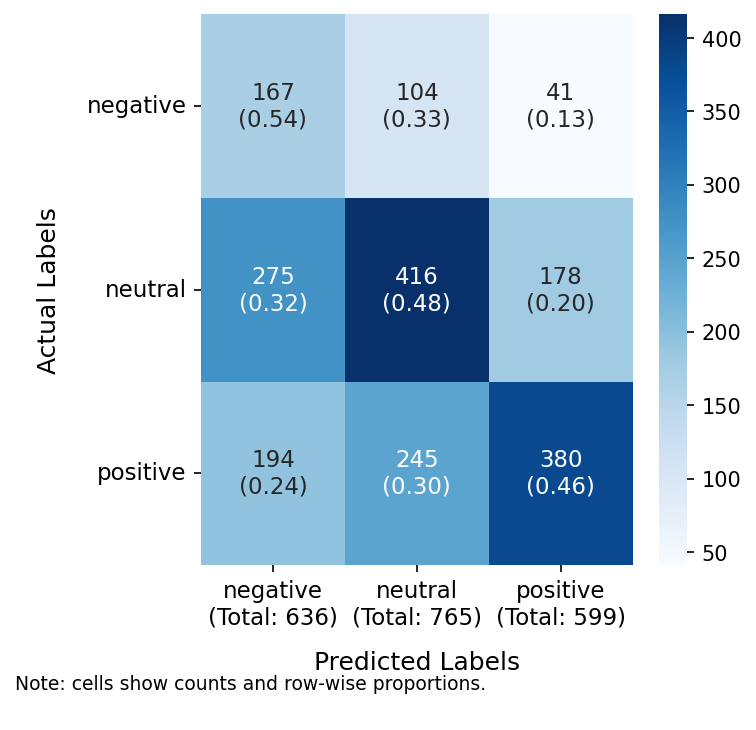


  bigrams  x  LR
              precision  recall  f1-score  support
negative          0.193   0.779     0.310      312
neutral           0.548   0.191     0.283      869
positive          0.590   0.316     0.412      819
accuracy          0.334   0.334     0.334        0
macro avg         0.444   0.429     0.335     2000
weighted avg      0.510   0.334     0.340     2000


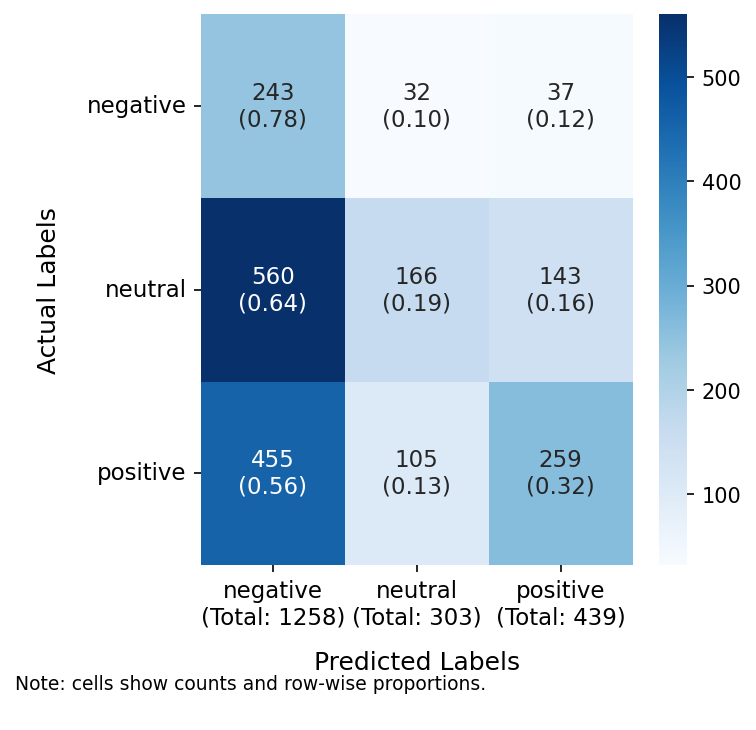


  uni+pos  x  LR
              precision  recall  f1-score  support
negative          0.268   0.561     0.362      312
neutral           0.567   0.483     0.522      869
positive          0.625   0.462     0.531      819
accuracy          0.486   0.486     0.486        0
macro avg         0.486   0.502     0.472     2000
weighted avg      0.544   0.486     0.501     2000


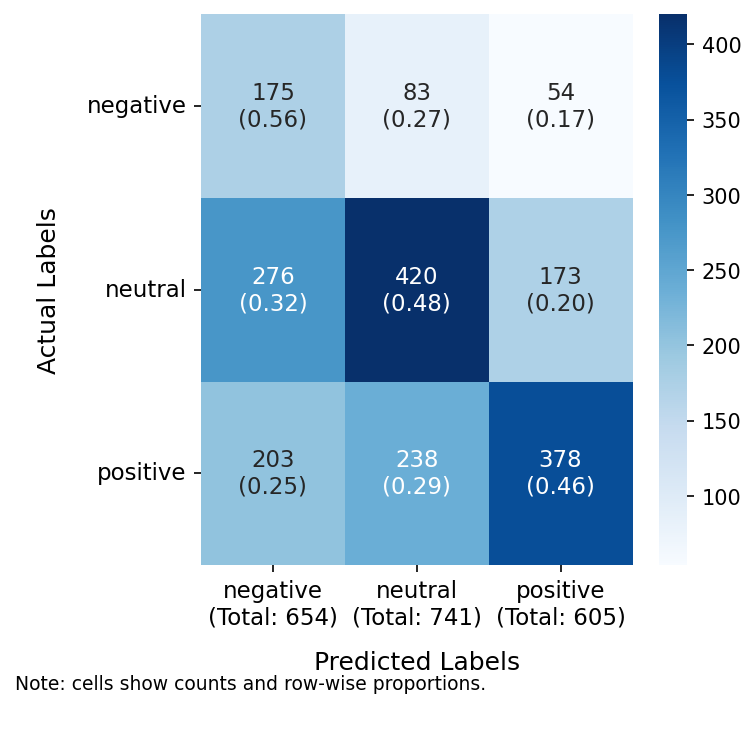


  textstats  x  LR
              precision  recall  f1-score  support
negative          0.204   0.484     0.287      312
neutral           0.524   0.391     0.448      869
positive          0.497   0.371     0.425      819
accuracy          0.398   0.398     0.398        0
macro avg         0.408   0.415     0.387     2000
weighted avg      0.463   0.398     0.413     2000


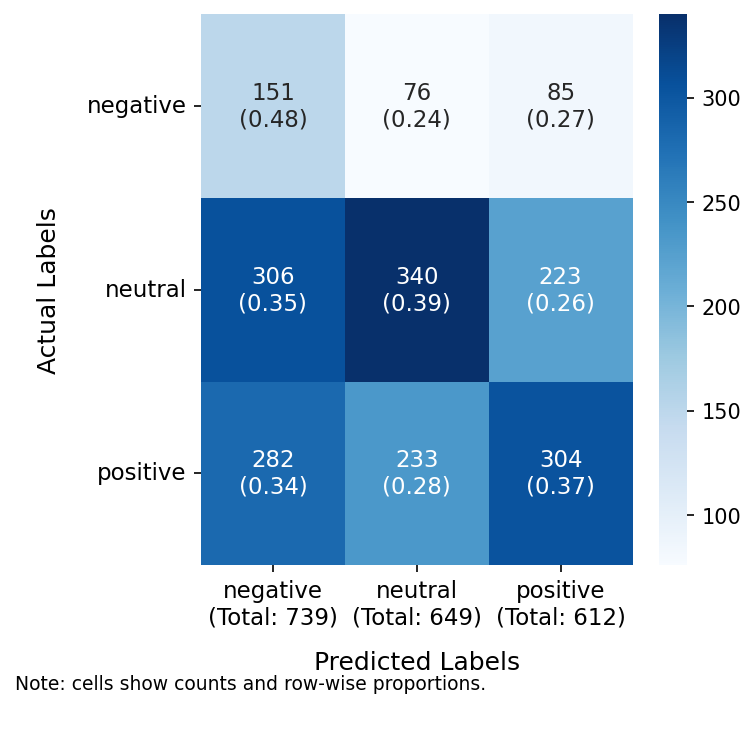


  lexicon  x  LR
              precision  recall  f1-score  support
negative          0.403   0.465     0.432      312
neutral           0.592   0.557     0.574      869
positive          0.613   0.615     0.614      819
accuracy          0.566   0.566     0.566        1
macro avg         0.536   0.546     0.540     2000
weighted avg      0.571   0.566     0.568     2000


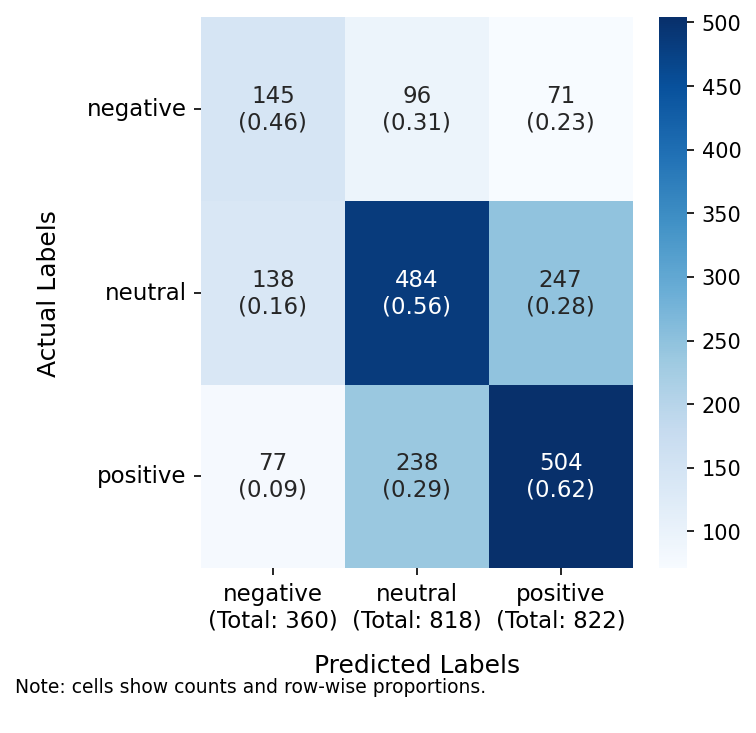


  embeddings  x  LR
              precision  recall  f1-score  support
negative          0.411   0.715     0.522      312
neutral           0.645   0.513     0.572      869
positive          0.701   0.656     0.678      819
accuracy          0.603   0.603     0.603        1
macro avg         0.586   0.628     0.590     2000
weighted avg      0.632   0.603     0.607     2000


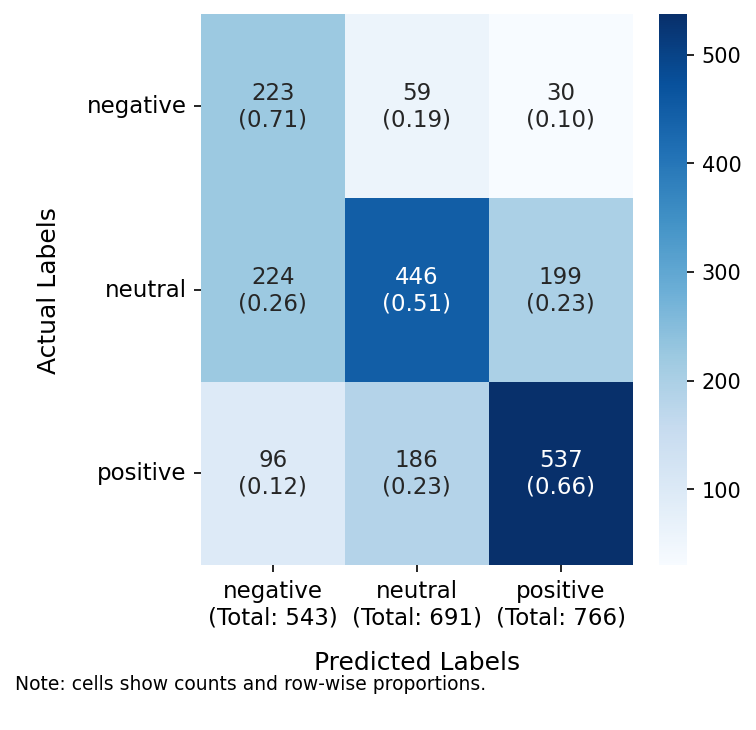


RUN 2: 3-CLASS + DECISION TREE

  unigrams  x  DT
              precision  recall  f1-score  support
negative          0.000   0.000     0.000      312
neutral           0.454   0.978     0.620      869
positive          0.794   0.122     0.212      819
accuracy          0.475   0.475     0.475        0
macro avg         0.416   0.367     0.277     2000
weighted avg      0.522   0.475     0.356     2000


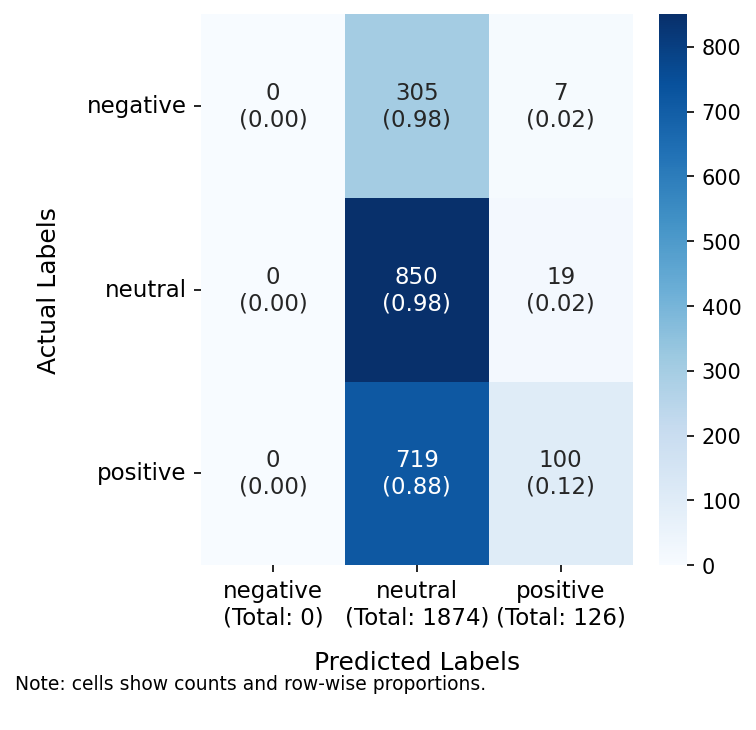


  bigrams  x  DT
              precision  recall  f1-score  support
negative          0.450   0.029     0.054      312
neutral           0.439   0.991     0.608      869
positive          0.824   0.017     0.033      819
accuracy          0.442   0.442     0.442        0
macro avg         0.571   0.346     0.232     2000
weighted avg      0.598   0.442     0.286     2000


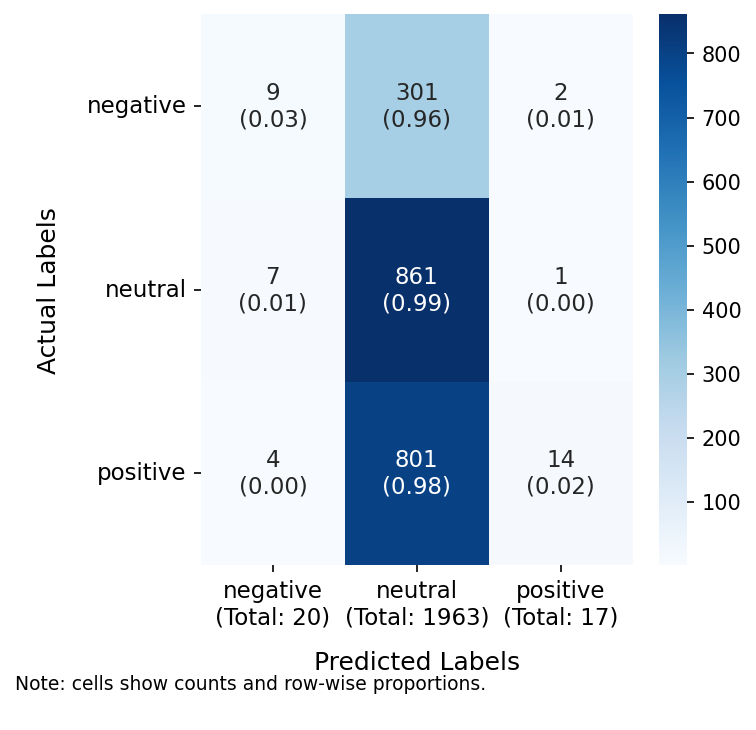


  uni+pos  x  DT
              precision  recall  f1-score  support
negative          0.203   0.532     0.294      312
neutral           0.467   0.583     0.519      869
positive          0.794   0.094     0.168      819
accuracy          0.375   0.375     0.375        0
macro avg         0.488   0.403     0.327     2000
weighted avg      0.560   0.375     0.340     2000


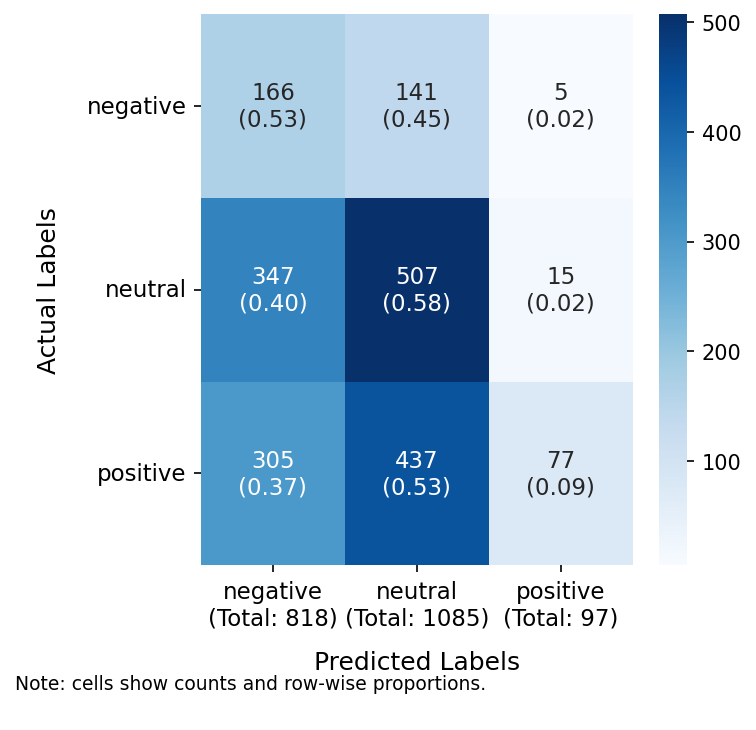


  textstats  x  DT
              precision  recall  f1-score  support
negative          0.209   0.558     0.304      312
neutral           0.582   0.221     0.320      869
positive          0.478   0.488     0.483      819
accuracy          0.383   0.383     0.383        0
macro avg         0.423   0.422     0.369     2000
weighted avg      0.481   0.383     0.384     2000


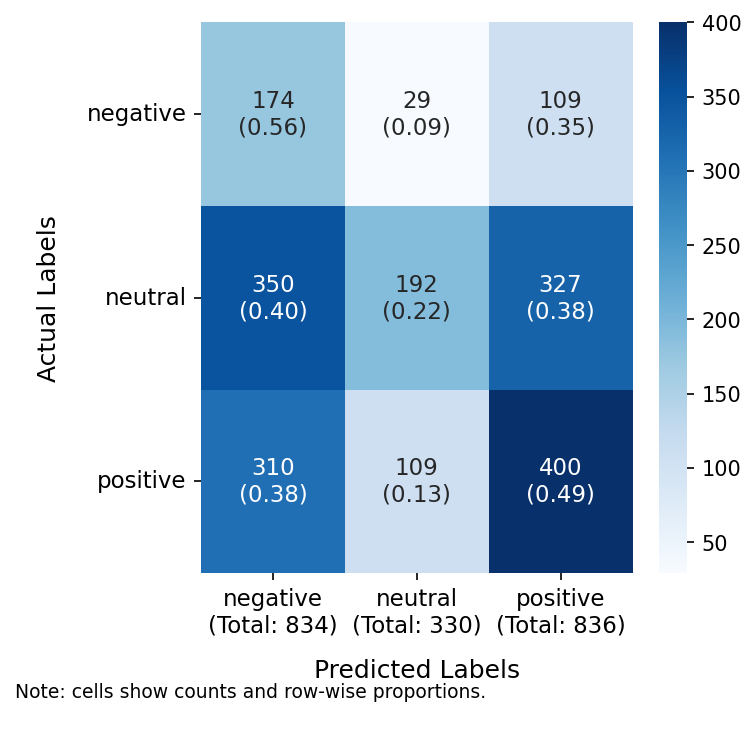


  lexicon  x  DT
              precision  recall  f1-score  support
negative          0.400   0.474     0.434      312
neutral           0.592   0.557     0.574      869
positive          0.613   0.608     0.611      819
accuracy          0.565   0.565     0.565        1
macro avg         0.535   0.546     0.539     2000
weighted avg      0.571   0.565     0.567     2000


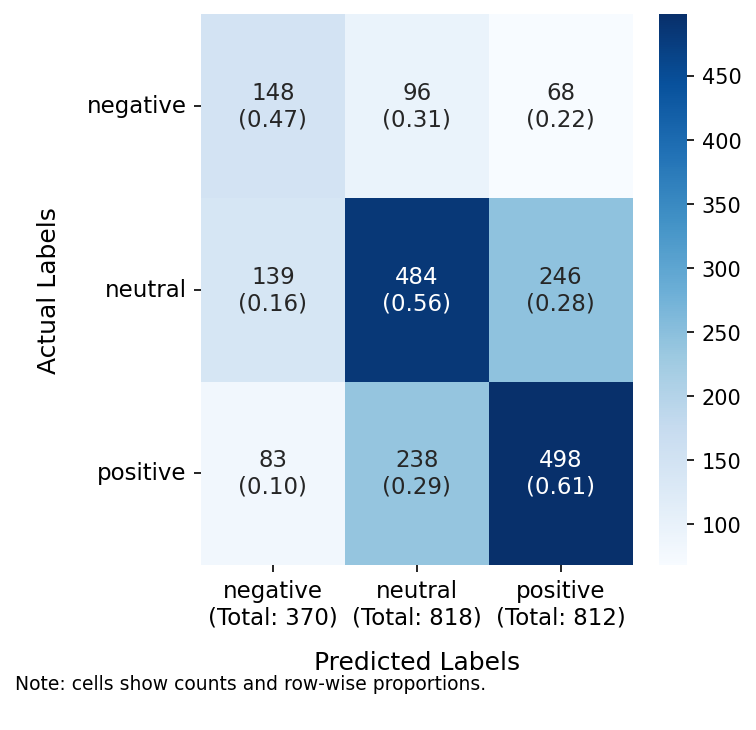


  embeddings  x  DT
              precision  recall  f1-score  support
negative          0.260   0.657     0.372      312
neutral           0.504   0.483     0.493      869
positive          0.621   0.286     0.391      819
accuracy          0.430   0.430     0.430        0
macro avg         0.461   0.475     0.419     2000
weighted avg      0.514   0.430     0.433     2000


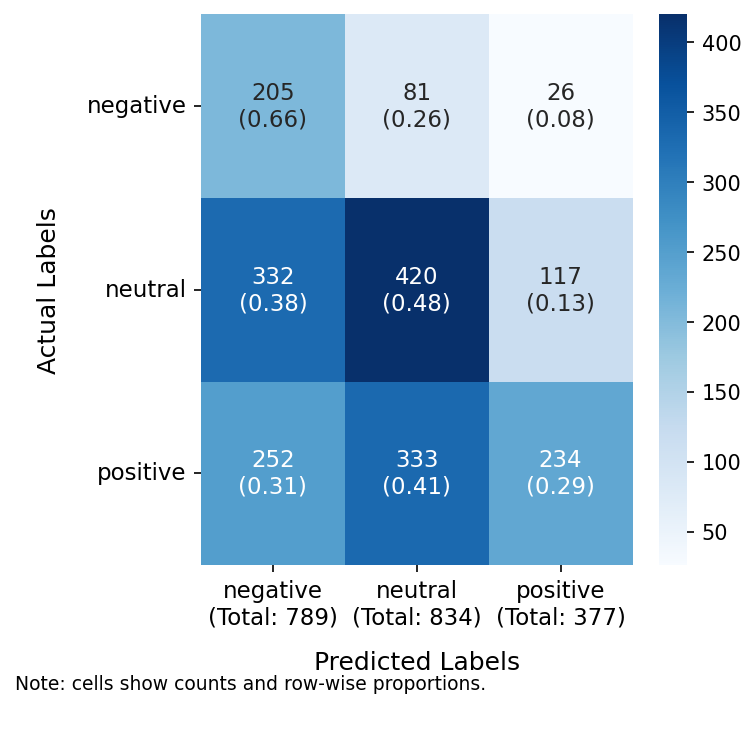


RUN 3: BINARY + LOGISTIC REGRESSION

  unigrams  x  LR
  MISSING : cm_run3_unigrams_LR.csv
  MISSING : cm_run3_unigrams_LR.png

  bigrams  x  LR
  MISSING : cm_run3_bigrams_LR.csv
  MISSING : cm_run3_bigrams_LR.png

  uni+pos  x  LR
  MISSING : cm_run3_uni+pos_LR.csv
  MISSING : cm_run3_uni+pos_LR.png

  textstats  x  LR
  MISSING : cm_run3_textstats_LR.csv
  MISSING : cm_run3_textstats_LR.png

  lexicon  x  LR
  MISSING : cm_run3_lexicon_LR.csv
  MISSING : cm_run3_lexicon_LR.png

  embeddings  x  LR
  MISSING : cm_run3_embeddings_LR.csv
  MISSING : cm_run3_embeddings_LR.png

RUN 4: BINARY + DECISION TREE

  unigrams  x  DT
  MISSING : cm_run4_unigrams_DT.csv
  MISSING : cm_run4_unigrams_DT.png

  bigrams  x  DT
  MISSING : cm_run4_bigrams_DT.csv
  MISSING : cm_run4_bigrams_DT.png

  uni+pos  x  DT
  MISSING : cm_run4_uni+pos_DT.csv
  MISSING : cm_run4_uni+pos_DT.png

  textstats  x  DT
  MISSING : cm_run4_textstats_DT.csv
  MISSING : cm_run4_textstats_DT.png

  lexicon  x  DT
  MISSI

In [25]:
run_specs = [
    ("RUN 1: 3-CLASS + LOGISTIC REGRESSION", 1, list(feat_configs.keys()), 'LR'),
    ("RUN 2: 3-CLASS + DECISION TREE",       2, list(feat_configs.keys()), 'DT'),
    ("RUN 3: BINARY + LOGISTIC REGRESSION",  3, list(feat_configs.keys()), 'LR'),
    ("RUN 4: BINARY + DECISION TREE",        4, list(feat_configs.keys()), 'DT'),
]

for run_title, run_num, feat_names_list, clf_name in run_specs:
    print(f"\n{run_title}")
    for feat_name in feat_names_list:
        stem     = f'cm_run{run_num}_{feat_name}_{clf_name}'
        csv_path = FIGS_DIR / f'{stem}.csv'
        fig_path = FIGS_DIR / f'{stem}.png'

        print(f'\n  {feat_name}  x  {clf_name}')

        if csv_path.exists():
            rpt_df = pd.read_csv(csv_path, index_col=0)
            numeric_cols = rpt_df.select_dtypes(include=[np.number]).columns
            rpt_df.loc[:, numeric_cols] = rpt_df.loc[:, numeric_cols].round(3)
            if 'support' in rpt_df.columns:
                rpt_df['support'] = rpt_df['support'].round().astype(int)
            print(rpt_df.to_string())
        else:
            print(f"  MISSING : {csv_path.name}")

        if fig_path.exists():
            display(Image(str(fig_path)))
        else:
            print(f"  MISSING : {fig_path.name}")

In [26]:
_best_bin_LR = save_run(3, "RUN 3: binary  + LR", results_binary_LR, 'LR', y_test_b, bin_classes, bin_names)


RUN 3: binary  + LR
    ok: report table cm_run3_unigrams_LR     -> cm_run3_unigrams_LR.csv (201 bytes)


    ok: confusion matrix cm_run3_unigrams_LR -> cm_run3_unigrams_LR.png (50,763 bytes)
    saved: unigrams_LR                       -> cm_run3_unigrams_LR


    ok: report table cm_run3_bigrams_LR      -> cm_run3_bigrams_LR.csv (198 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run3_bigrams_LR  -> cm_run3_bigrams_LR.png (54,634 bytes)
    saved: bigrams_LR                        -> cm_run3_bigrams_LR
    ok: report table cm_run3_uni+pos_LR      -> cm_run3_uni+pos_LR.csv (198 bytes)


    ok: confusion matrix cm_run3_uni+pos_LR  -> cm_run3_uni+pos_LR.png (50,980 bytes)
    saved: uni+pos_LR                        -> cm_run3_uni+pos_LR
    ok: report table cm_run3_textstats_LR    -> cm_run3_textstats_LR.csv (198 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run3_textstats_LR -> cm_run3_textstats_LR.png (51,596 bytes)
    saved: textstats_LR                      -> cm_run3_textstats_LR
    ok: report table cm_run3_lexicon_LR      -> cm_run3_lexicon_LR.csv (201 bytes)


    ok: confusion matrix cm_run3_lexicon_LR  -> cm_run3_lexicon_LR.png (54,008 bytes)
    saved: lexicon_LR                        -> cm_run3_lexicon_LR
    ok: report table cm_run3_embeddings_LR   -> cm_run3_embeddings_LR.csv (201 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run3_embeddings_LR -> cm_run3_embeddings_LR.png (51,988 bytes)
    saved: embeddings_LR                     -> cm_run3_embeddings_LR
    best: embeddings x LR                    -> macro F1 = 0.806


In [27]:
_best_bin_DT = save_run(4, "RUN 4: binary  + DT", results_binary_DT, 'DT', y_test_b, bin_classes, bin_names)


RUN 4: binary  + DT
    ok: report table cm_run4_unigrams_DT     -> cm_run4_unigrams_DT.csv (197 bytes)


    ok: confusion matrix cm_run4_unigrams_DT -> cm_run4_unigrams_DT.png (53,267 bytes)
    saved: unigrams_DT                       -> cm_run4_unigrams_DT


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: report table cm_run4_bigrams_DT      -> cm_run4_bigrams_DT.csv (201 bytes)
    ok: confusion matrix cm_run4_bigrams_DT  -> cm_run4_bigrams_DT.png (52,864 bytes)
    saved: bigrams_DT                        -> cm_run4_bigrams_DT
    ok: report table cm_run4_uni+pos_DT      -> cm_run4_uni+pos_DT.csv (200 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run4_uni+pos_DT  -> cm_run4_uni+pos_DT.png (56,107 bytes)
    saved: uni+pos_DT                        -> cm_run4_uni+pos_DT
    ok: report table cm_run4_textstats_DT    -> cm_run4_textstats_DT.csv (200 bytes)
    ok: confusion matrix cm_run4_textstats_DT -> cm_run4_textstats_DT.png (53,237 bytes)
    saved: textstats_DT                      -> cm_run4_textstats_DT
    ok: report table cm_run4_lexicon_DT      -> cm_run4_lexicon_DT.csv (200 bytes)


D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
D:\Python\Lib\site-packages\textplumber\report.py:380: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    ok: confusion matrix cm_run4_lexicon_DT  -> cm_run4_lexicon_DT.png (53,950 bytes)
    saved: lexicon_DT                        -> cm_run4_lexicon_DT
    ok: report table cm_run4_embeddings_DT   -> cm_run4_embeddings_DT.csv (201 bytes)
    ok: confusion matrix cm_run4_embeddings_DT -> cm_run4_embeddings_DT.png (53,943 bytes)
    saved: embeddings_DT                     -> cm_run4_embeddings_DT
    best: lexicon x DT                       -> macro F1 = 0.638


In [28]:
feat_names = list(feat_configs.keys())
col = 8

print(f"\n{'3-CLASS TASK':48}")
print(f"{'Feature set':14}  {'LR':>{col}}  {'DT':>{col}}")
print('-' * 40)
for fn in feat_names:
    f1_lr = results_3class_LR[(fn, 'LR')]['macro_f1']
    f1_dt = results_3class_DT[(fn, 'DT')]['macro_f1']
    print(f"{fn:14}  {f1_lr:>{col}.3f}  {f1_dt:>{col}.3f}")

print(f"\n{'BINARY TASK':48}")
print(f"{'Feature set':14}  {'LR':>{col}}  {'DT':>{col}}")
print('-' * 40)
for fn in feat_names:
    f1_lr = results_binary_LR[(fn, 'LR')]['macro_f1']
    f1_dt = results_binary_DT[(fn, 'DT')]['macro_f1']
    print(f"{fn:14}  {f1_lr:>{col}.3f}  {f1_dt:>{col}.3f}")


3-CLASS TASK                                    
Feature set           LR        DT
----------------------------------------
unigrams           0.466     0.277
bigrams            0.335     0.232
uni+pos            0.472     0.327
textstats          0.387     0.369
lexicon            0.540     0.539
embeddings         0.590     0.419

BINARY TASK                                     
Feature set           LR        DT
----------------------------------------
unigrams           0.667     0.521
bigrams            0.525     0.448
uni+pos            0.650     0.562
textstats          0.540     0.553
lexicon            0.639     0.638
embeddings         0.806     0.614


In [29]:
print(f"\n{'LOGISTIC REGRESSION':48}")
print(f"{'Feature set':14}  {'3-class':>8}  {'binary':>8}  {'gain':>8}")
print('-' * 52)
for fn in feat_names:
    f1_3 = results_3class_LR[(fn, 'LR')]['macro_f1']
    f1_b = results_binary_LR[(fn, 'LR')]['macro_f1']
    print(f"{fn:14}  {f1_3:>8.3f}  {f1_b:>8.3f}  {f1_b - f1_3:>+8.3f}")

print(f"\n{'DECISION TREE':48}")
print(f"{'Feature set':14}  {'3-class':>8}  {'binary':>8}  {'gain':>8}")
print('-' * 52)
for fn in feat_names:
    f1_3 = results_3class_DT[(fn, 'DT')]['macro_f1']
    f1_b = results_binary_DT[(fn, 'DT')]['macro_f1']
    print(f"{fn:14}  {f1_3:>8.3f}  {f1_b:>8.3f}  {f1_b - f1_3:>+8.3f}")


LOGISTIC REGRESSION                             
Feature set      3-class    binary      gain
----------------------------------------------------
unigrams           0.466     0.667    +0.201
bigrams            0.335     0.525    +0.190
uni+pos            0.472     0.650    +0.178
textstats          0.387     0.540    +0.154
lexicon            0.540     0.639    +0.099
embeddings         0.590     0.806    +0.216

DECISION TREE                                   
Feature set      3-class    binary      gain
----------------------------------------------------
unigrams           0.277     0.521    +0.244
bigrams            0.232     0.448    +0.217
uni+pos            0.327     0.562    +0.235
textstats          0.369     0.553    +0.184
lexicon            0.539     0.638    +0.098
embeddings         0.419     0.614    +0.195


## 4. Evaluate your model and investigate model predictions

You already have some metrics in the cell above. Below is some additional reporting to help you understand your model.

### 4.1 Classifier-specific features

If you are using a Decision Tree classifier in your pipeline, this will plot it ...

In [30]:
if pipeline.named_steps['classifier'].__class__.__name__ == 'DecisionTreeClassifier':
    fig_path = FIGS_DIR / 'decision_tree.png'
    with plt.ioff():
        plot_decision_tree_from_pipeline(pipeline, X_train, y_train, target_classes, target_names, 'classifier', 'features')
        plt.savefig(fig_path, bbox_inches='tight', dpi=150)
        plt.close('all')
    print(f"  [saved] decision_tree.png")
else:
    print('The classifier is not a decision tree - so no plot is shown!')

The classifier is not a decision tree - so no plot is shown!


If you are using a Logistic Regression classifier in your pipeline, this will plot the coefficients of the features in the model.


In [31]:
if pipeline.named_steps['classifier'].__class__.__name__ == 'LogisticRegression':
    try:
        fig_path = FIGS_DIR / 'lr_features.png'
        with plt.ioff():
            plot_logistic_regression_features_from_pipeline(pipeline, target_classes, target_names, top_n=20, classifier_step_name='classifier', features_step_name='features')
            plt.savefig(fig_path, bbox_inches='tight', dpi=150)
            plt.close('all')
        print(f"  [saved] lr_features.png")
    except AttributeError:
        print("[SKIP] plot_logistic_regression_features_from_pipeline: TokensVectorizer does not support get_feature_names_out()")

[SKIP] plot_logistic_regression_features_from_pipeline: TokensVectorizer does not support get_feature_names_out()



RUN 1: 3-CLASS + LOGISTIC REGRESSION

  unigrams  x  LR
              precision  recall  f1-score  support
negative          0.263   0.535     0.352      312
neutral           0.544   0.479     0.509      869
positive          0.634   0.464     0.536      819
accuracy          0.482   0.482     0.482        0
macro avg         0.480   0.493     0.466     2000
weighted avg      0.537   0.482     0.496     2000


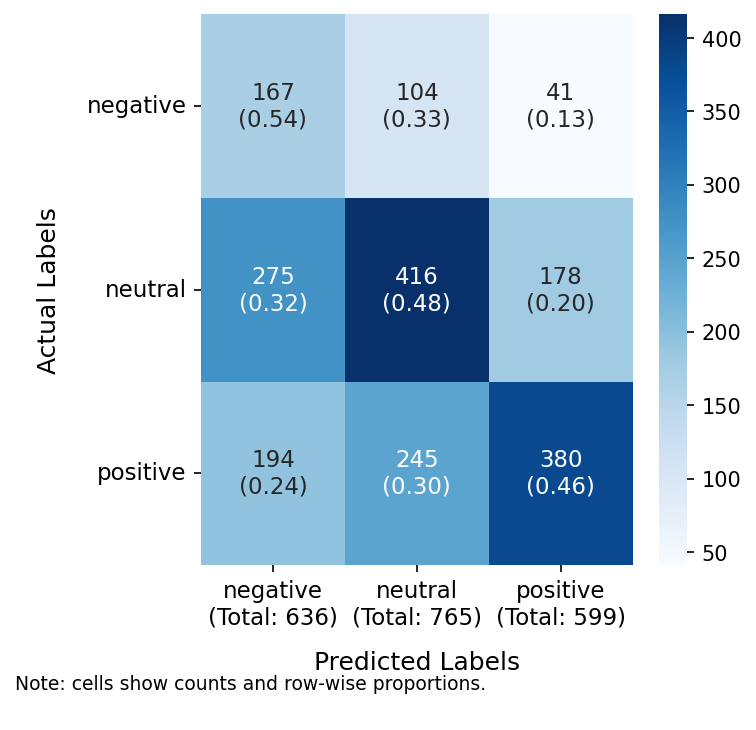


  bigrams  x  LR
              precision  recall  f1-score  support
negative          0.193   0.779     0.310      312
neutral           0.548   0.191     0.283      869
positive          0.590   0.316     0.412      819
accuracy          0.334   0.334     0.334        0
macro avg         0.444   0.429     0.335     2000
weighted avg      0.510   0.334     0.340     2000


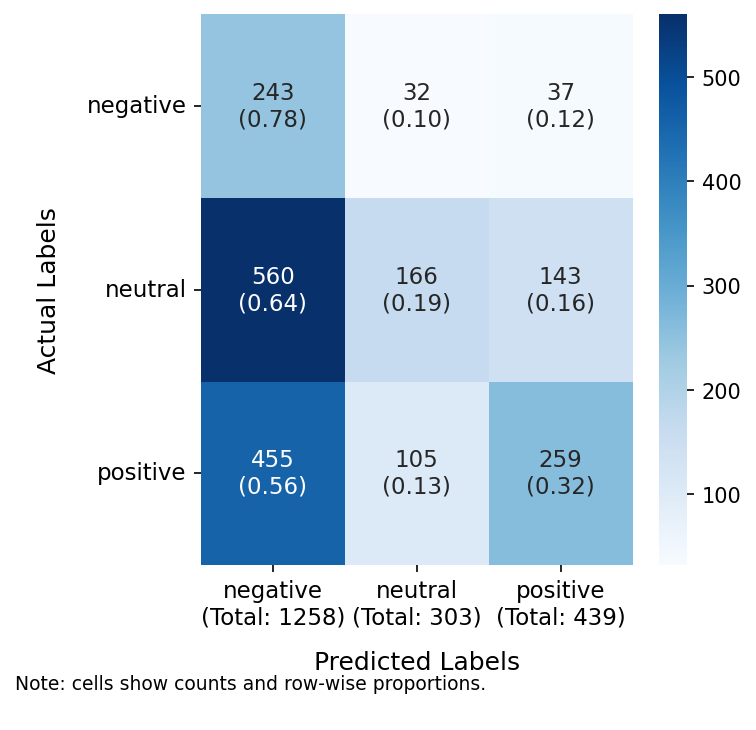


  uni+pos  x  LR
              precision  recall  f1-score  support
negative          0.268   0.561     0.362      312
neutral           0.567   0.483     0.522      869
positive          0.625   0.462     0.531      819
accuracy          0.486   0.486     0.486        0
macro avg         0.486   0.502     0.472     2000
weighted avg      0.544   0.486     0.501     2000


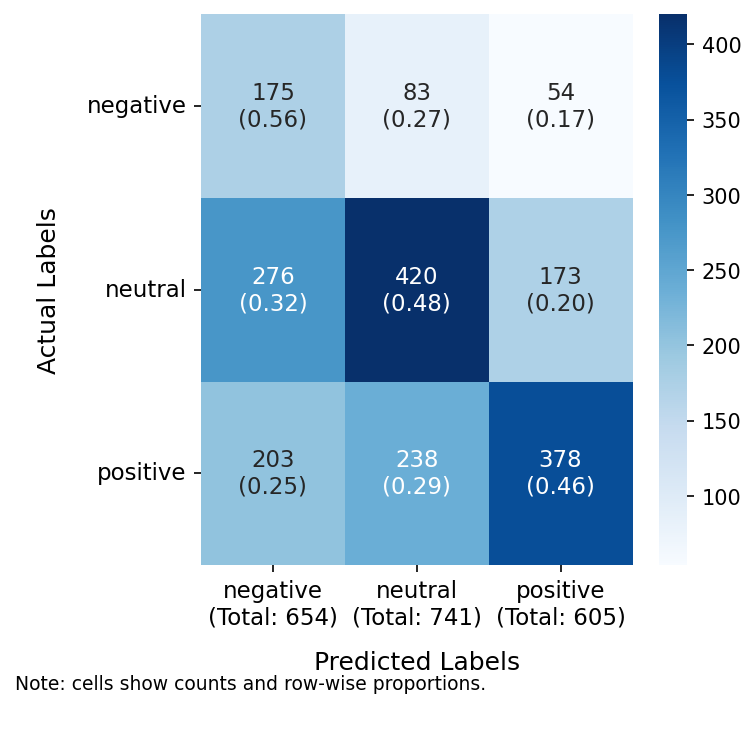


  textstats  x  LR
              precision  recall  f1-score  support
negative          0.204   0.484     0.287      312
neutral           0.524   0.391     0.448      869
positive          0.497   0.371     0.425      819
accuracy          0.398   0.398     0.398        0
macro avg         0.408   0.415     0.387     2000
weighted avg      0.463   0.398     0.413     2000


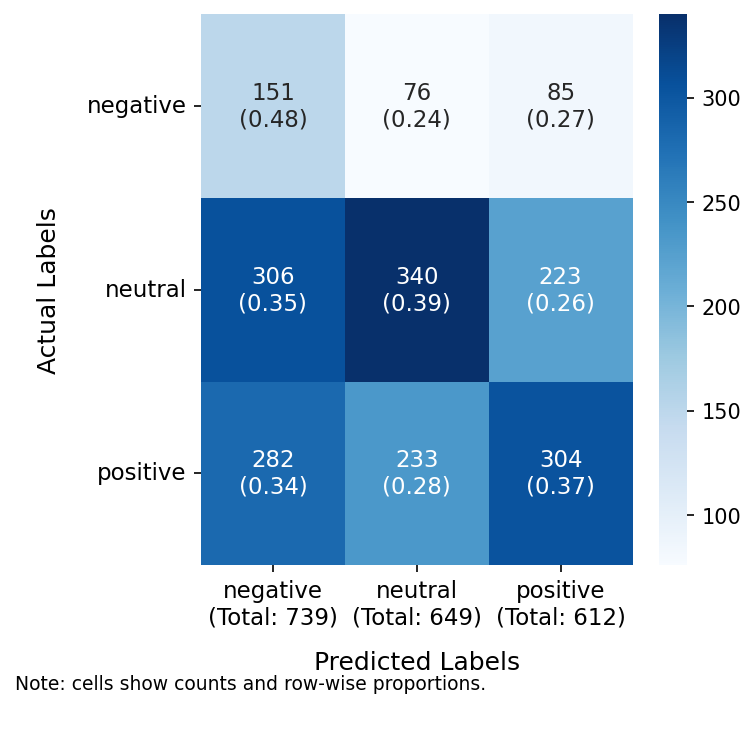


  lexicon  x  LR
              precision  recall  f1-score  support
negative          0.403   0.465     0.432      312
neutral           0.592   0.557     0.574      869
positive          0.613   0.615     0.614      819
accuracy          0.566   0.566     0.566        1
macro avg         0.536   0.546     0.540     2000
weighted avg      0.571   0.566     0.568     2000


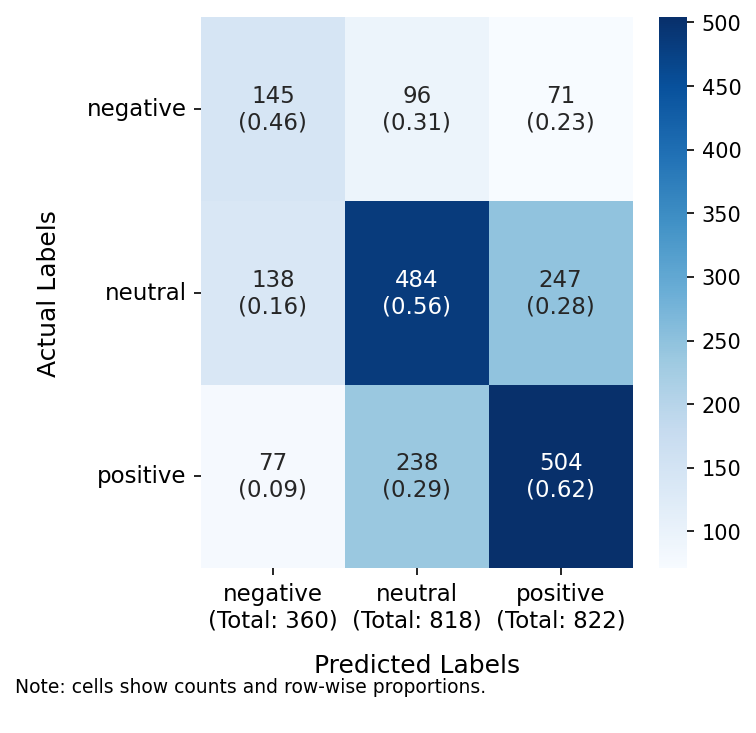


  embeddings  x  LR
              precision  recall  f1-score  support
negative          0.411   0.715     0.522      312
neutral           0.645   0.513     0.572      869
positive          0.701   0.656     0.678      819
accuracy          0.603   0.603     0.603        1
macro avg         0.586   0.628     0.590     2000
weighted avg      0.632   0.603     0.607     2000


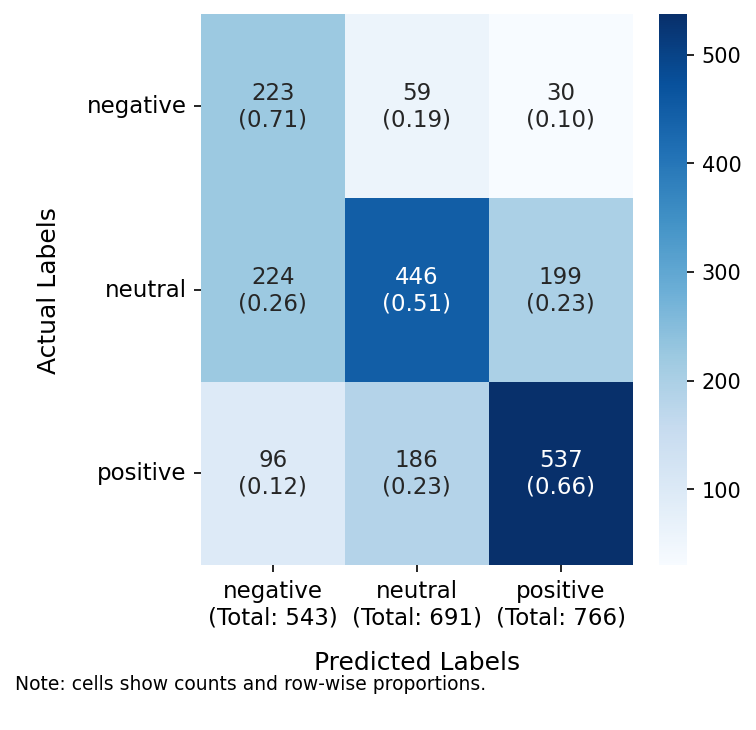


RUN 2: 3-CLASS + DECISION TREE

  unigrams  x  DT
              precision  recall  f1-score  support
negative          0.000   0.000     0.000      312
neutral           0.454   0.978     0.620      869
positive          0.794   0.122     0.212      819
accuracy          0.475   0.475     0.475        0
macro avg         0.416   0.367     0.277     2000
weighted avg      0.522   0.475     0.356     2000


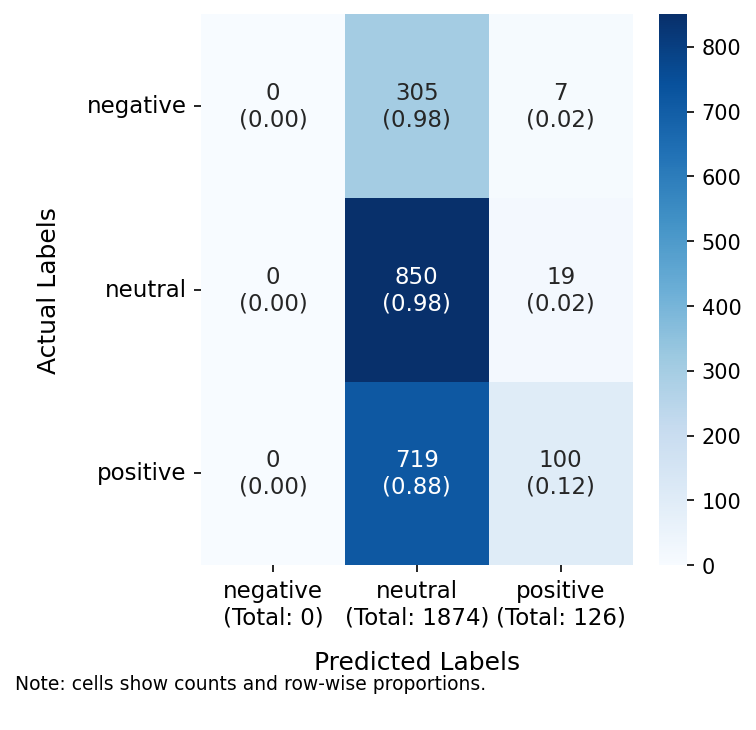


  bigrams  x  DT
              precision  recall  f1-score  support
negative          0.450   0.029     0.054      312
neutral           0.439   0.991     0.608      869
positive          0.824   0.017     0.033      819
accuracy          0.442   0.442     0.442        0
macro avg         0.571   0.346     0.232     2000
weighted avg      0.598   0.442     0.286     2000


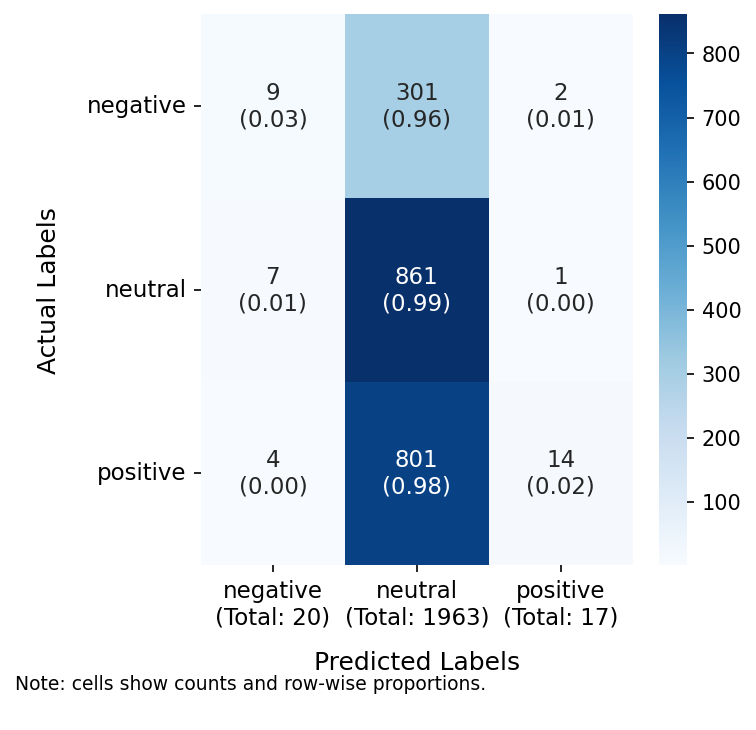


  uni+pos  x  DT
              precision  recall  f1-score  support
negative          0.203   0.532     0.294      312
neutral           0.467   0.583     0.519      869
positive          0.794   0.094     0.168      819
accuracy          0.375   0.375     0.375        0
macro avg         0.488   0.403     0.327     2000
weighted avg      0.560   0.375     0.340     2000


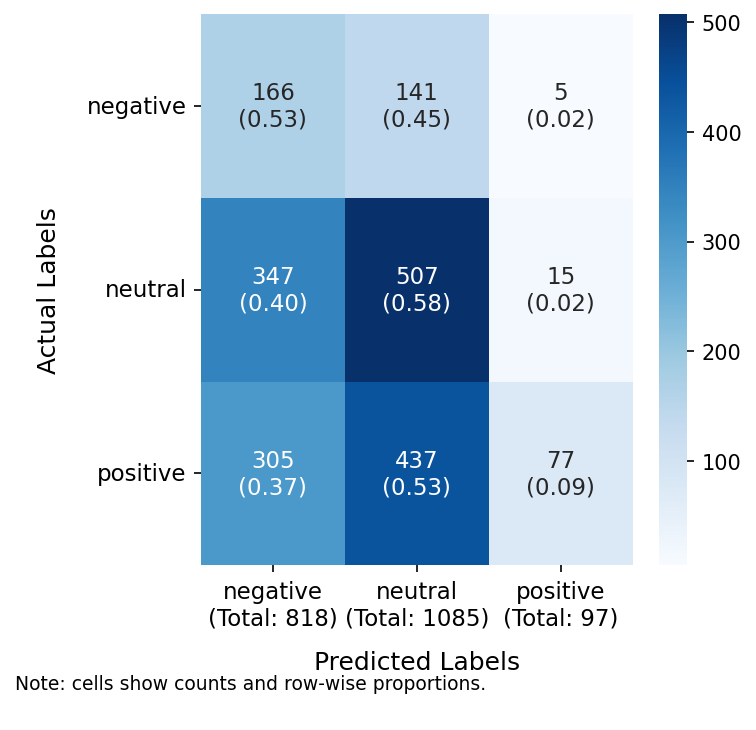


  textstats  x  DT
              precision  recall  f1-score  support
negative          0.209   0.558     0.304      312
neutral           0.582   0.221     0.320      869
positive          0.478   0.488     0.483      819
accuracy          0.383   0.383     0.383        0
macro avg         0.423   0.422     0.369     2000
weighted avg      0.481   0.383     0.384     2000


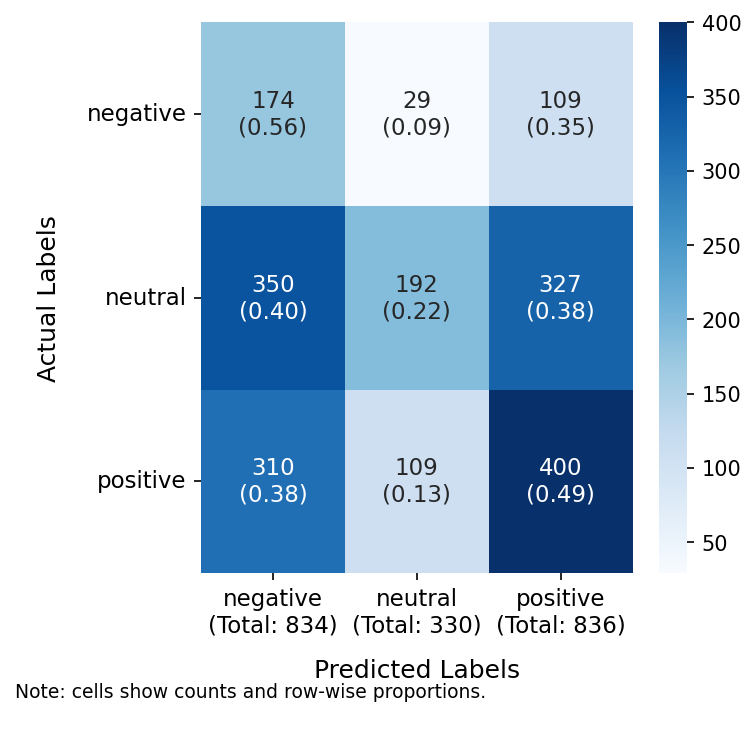


  lexicon  x  DT
              precision  recall  f1-score  support
negative          0.400   0.474     0.434      312
neutral           0.592   0.557     0.574      869
positive          0.613   0.608     0.611      819
accuracy          0.565   0.565     0.565        1
macro avg         0.535   0.546     0.539     2000
weighted avg      0.571   0.565     0.567     2000


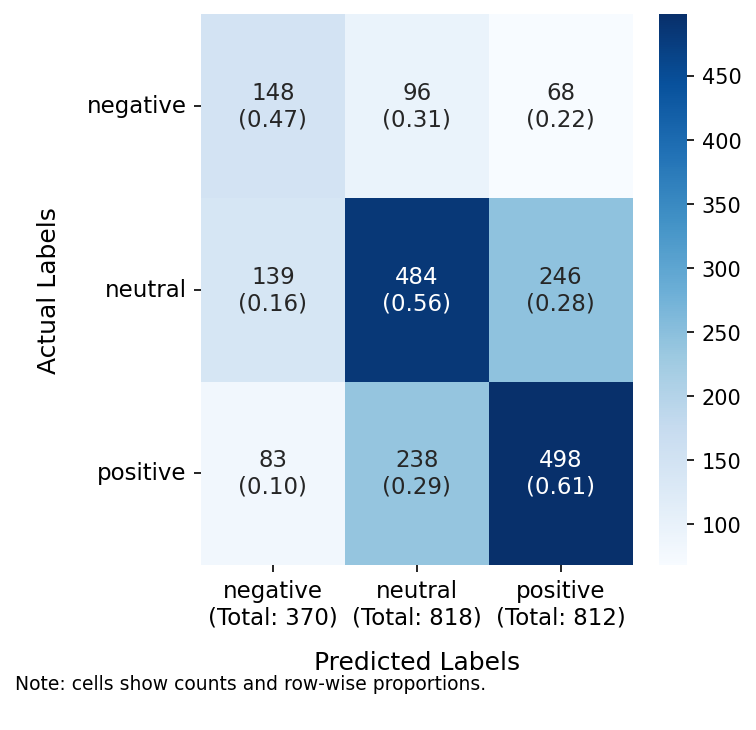


  embeddings  x  DT
              precision  recall  f1-score  support
negative          0.260   0.657     0.372      312
neutral           0.504   0.483     0.493      869
positive          0.621   0.286     0.391      819
accuracy          0.430   0.430     0.430        0
macro avg         0.461   0.475     0.419     2000
weighted avg      0.514   0.430     0.433     2000


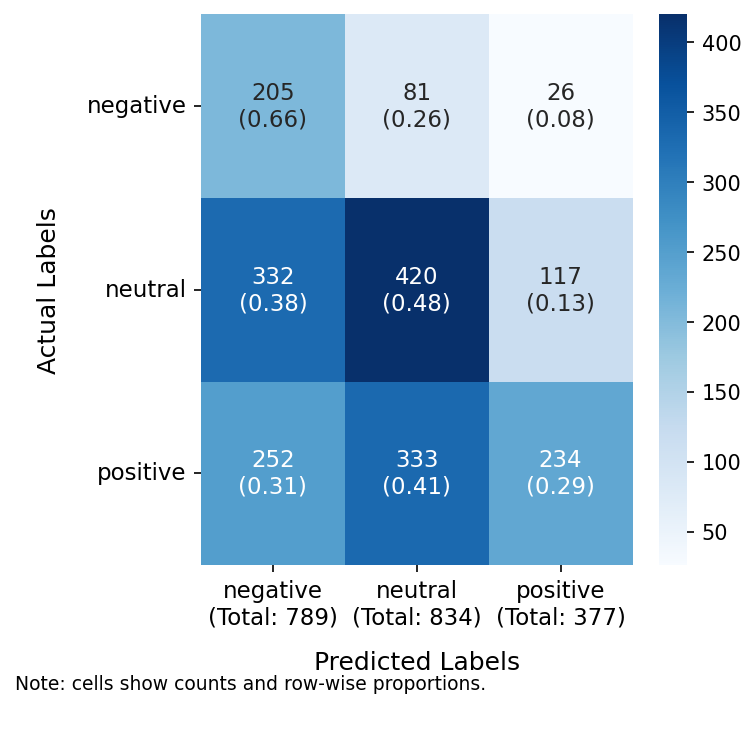


RUN 3: BINARY + LOGISTIC REGRESSION

  unigrams  x  LR
              precision  recall  f1-score  support
negative          0.464   0.753     0.575      312
positive          0.877   0.669     0.759      819
accuracy          0.692   0.692     0.692        1
macro avg         0.671   0.711     0.667     1131
weighted avg      0.763   0.692     0.708     1131


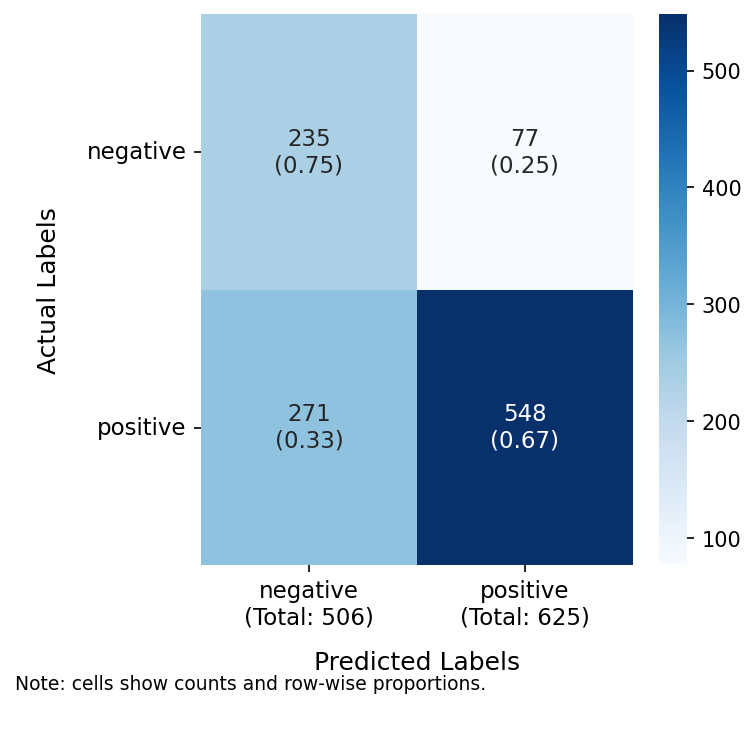


  bigrams  x  LR
              precision  recall  f1-score  support
negative          0.353   0.859     0.500      312
positive          0.881   0.399     0.550      819
accuracy          0.526   0.526     0.526        1
macro avg         0.617   0.629     0.525     1131
weighted avg      0.736   0.526     0.536     1131


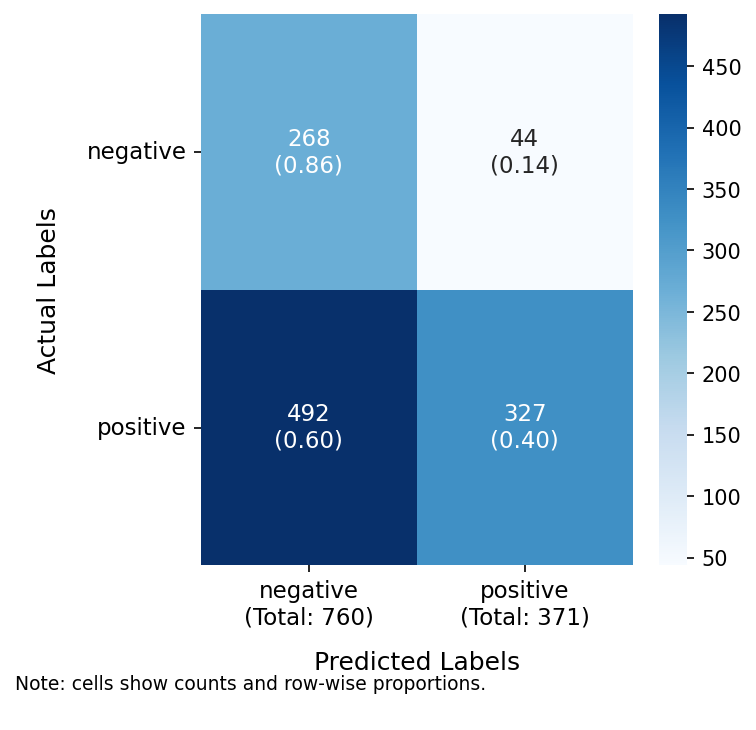


  uni+pos  x  LR
              precision  recall  f1-score  support
negative          0.446   0.740     0.557      312
positive          0.868   0.650     0.743      819
accuracy          0.675   0.675     0.675        1
macro avg         0.657   0.695     0.650     1131
weighted avg      0.751   0.675     0.692     1131


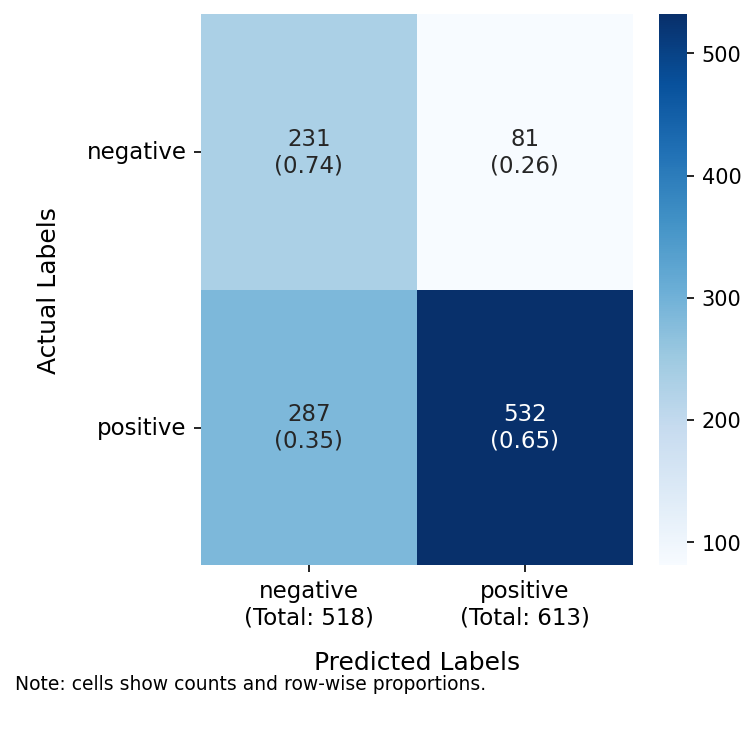


  textstats  x  LR
              precision  recall  f1-score  support
negative          0.340   0.622     0.439      312
positive          0.789   0.540     0.641      819
accuracy          0.562   0.562     0.562        1
macro avg         0.565   0.581     0.540     1131
weighted avg      0.665   0.562     0.585     1131


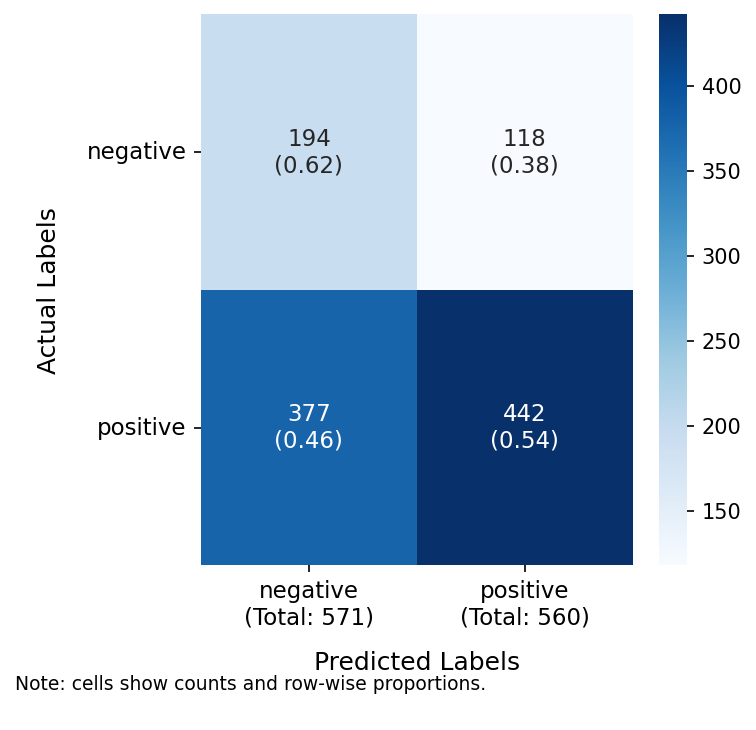


  lexicon  x  LR
              precision  recall  f1-score  support
negative          0.433   0.772     0.555      312
positive          0.877   0.615     0.723      819
accuracy          0.659   0.659     0.659        1
macro avg         0.655   0.694     0.639     1131
weighted avg      0.754   0.659     0.677     1131


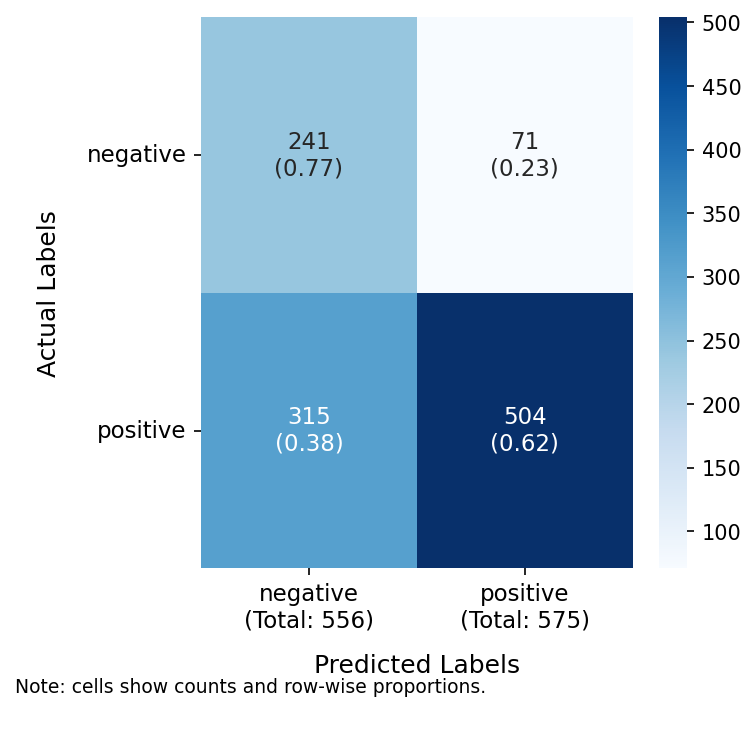


  embeddings  x  LR
              precision  recall  f1-score  support
negative          0.646   0.856     0.737      312
positive          0.937   0.822     0.876      819
accuracy          0.831   0.831     0.831        1
macro avg         0.792   0.839     0.806     1131
weighted avg      0.857   0.831     0.837     1131


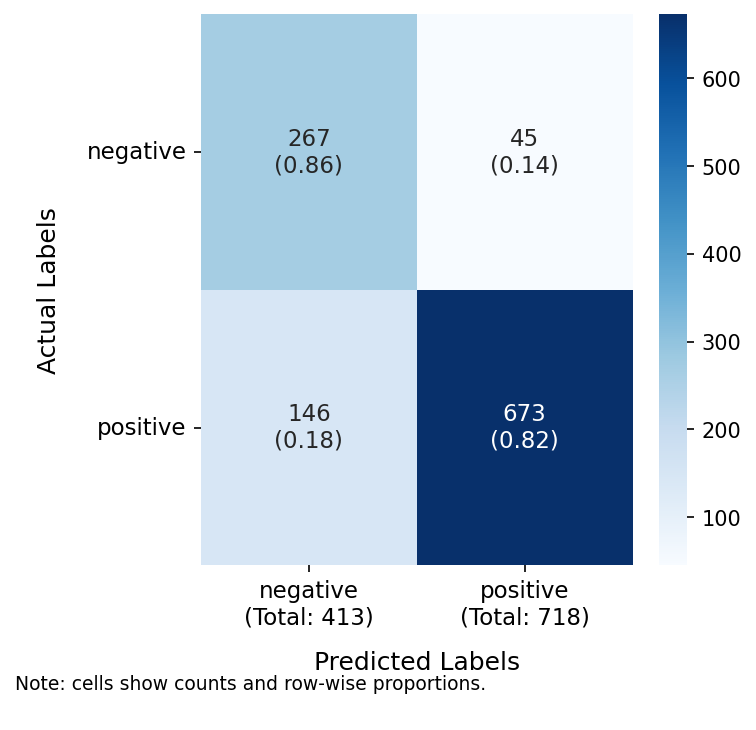


RUN 4: BINARY + DECISION TREE

  unigrams  x  DT
              precision  recall  f1-score  support
negative          0.351   0.189     0.246      312
positive          0.737   0.867     0.797      819
accuracy          0.680   0.680     0.680        1
macro avg         0.544   0.528     0.521     1131
weighted avg      0.631   0.680     0.645     1131


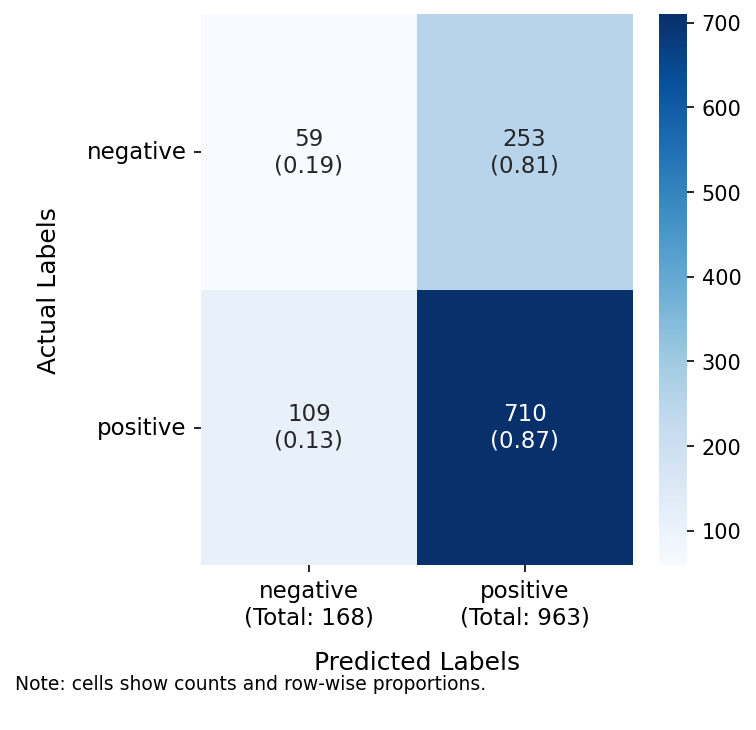


  bigrams  x  DT
              precision  recall  f1-score  support
negative          0.692   0.029     0.055      312
positive          0.729   0.995     0.842      819
accuracy          0.729   0.729     0.729        1
macro avg         0.711   0.512     0.448     1131
weighted avg      0.719   0.729     0.625     1131


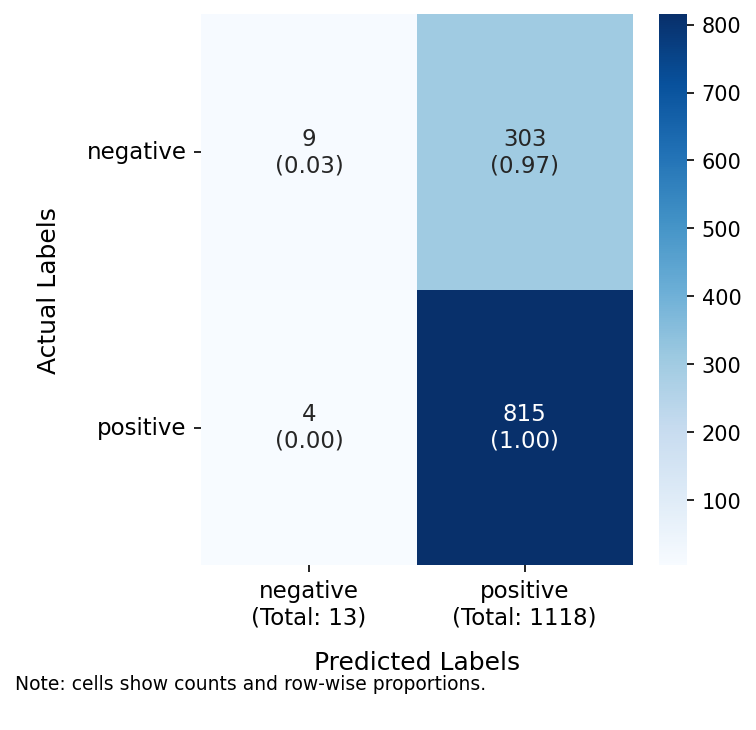


  uni+pos  x  DT
              precision  recall  f1-score  support
negative          0.356   0.449     0.397      312
positive          0.767   0.691     0.727      819
accuracy          0.624   0.624     0.624        1
macro avg         0.562   0.570     0.562     1131
weighted avg      0.654   0.624     0.636     1131


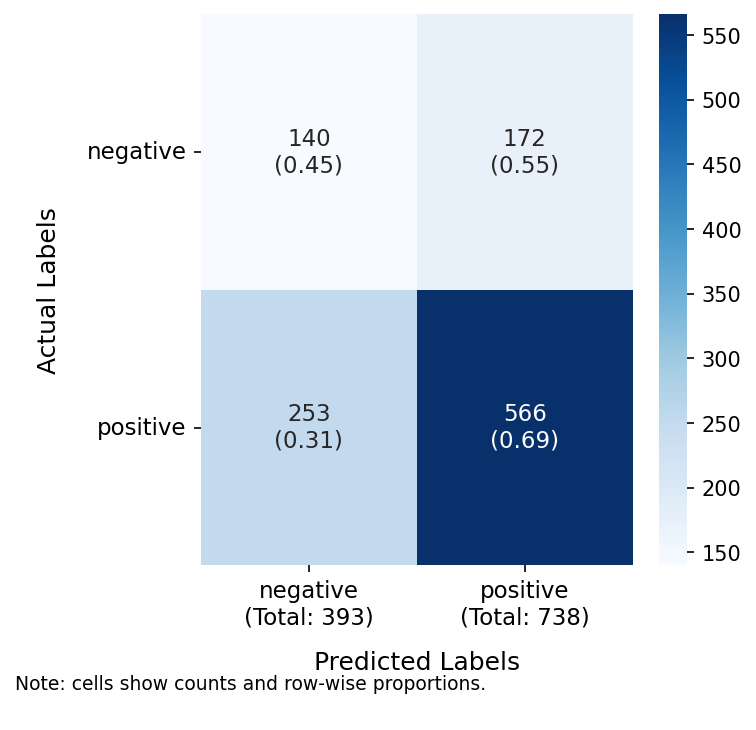


  textstats  x  DT


              precision  recall  f1-score  support
negative          0.349   0.599     0.441      312
positive          0.790   0.574     0.665      819
accuracy          0.581   0.581     0.581        1
macro avg         0.569   0.587     0.553     1131
weighted avg      0.668   0.581     0.603     1131


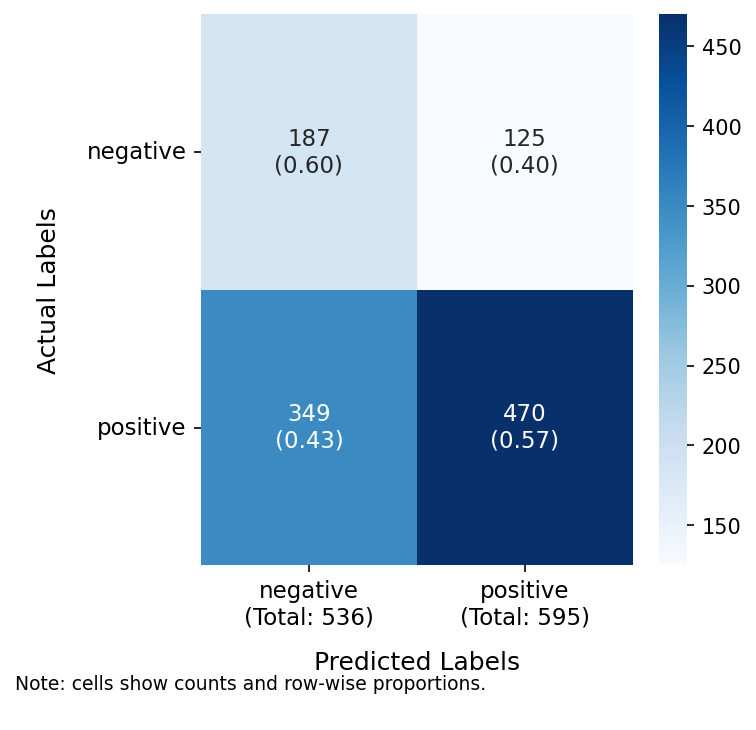


  lexicon  x  DT
              precision  recall  f1-score  support
negative          0.432   0.782     0.556      312
positive          0.880   0.608     0.719      819
accuracy          0.656   0.656     0.656        1
macro avg         0.656   0.695     0.638     1131
weighted avg      0.756   0.656     0.674     1131


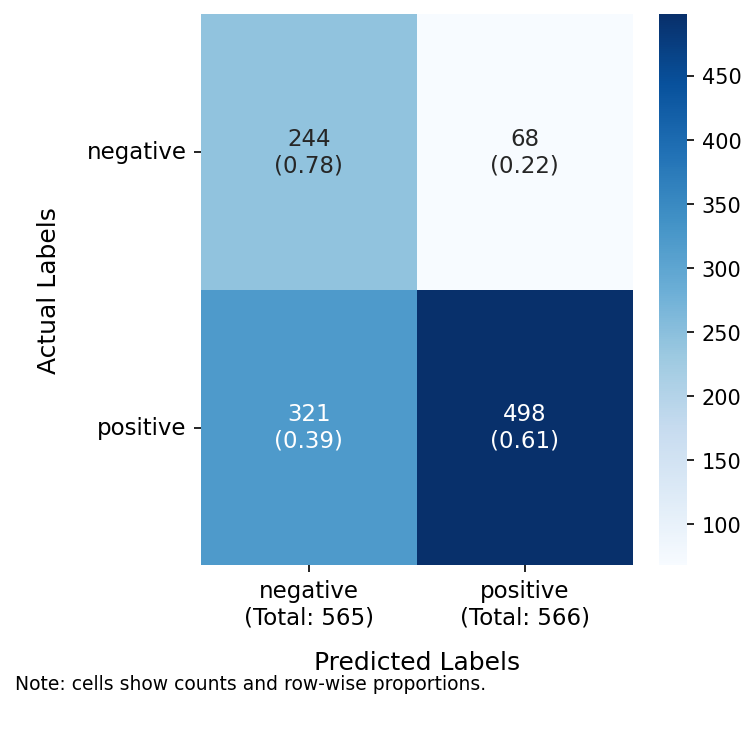


  embeddings  x  DT
              precision  recall  f1-score  support
negative          0.411   0.811     0.545      312
positive          0.885   0.557     0.684      819
accuracy          0.627   0.627     0.627        1
macro avg         0.648   0.684     0.614     1131
weighted avg      0.754   0.627     0.645     1131


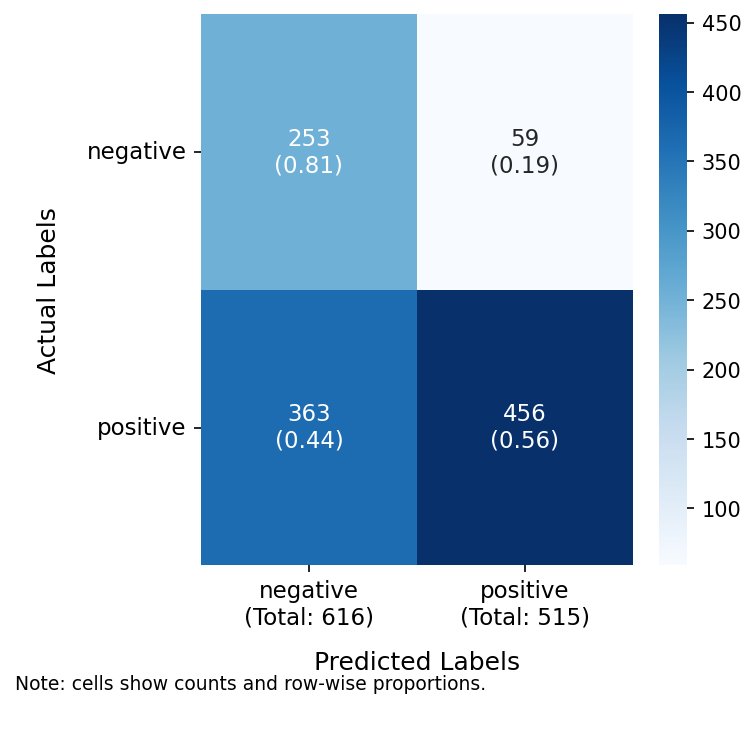

In [32]:
run_specs = [
    ("RUN 1: 3-CLASS + LOGISTIC REGRESSION", 1, list(feat_configs.keys()), 'LR'),
    ("RUN 2: 3-CLASS + DECISION TREE",       2, list(feat_configs.keys()), 'DT'),
    ("RUN 3: BINARY + LOGISTIC REGRESSION",  3, list(feat_configs.keys()), 'LR'),
    ("RUN 4: BINARY + DECISION TREE",        4, list(feat_configs.keys()), 'DT'),
]

for run_title, run_num, feat_names_list, clf_name in run_specs:
    print(f"\n{run_title}")
    for feat_name in feat_names_list:
        stem     = f'cm_run{run_num}_{feat_name}_{clf_name}'
        csv_path = FIGS_DIR / f'{stem}.csv'
        fig_path = FIGS_DIR / f'{stem}.png'

        print(f'\n  {feat_name}  x  {clf_name}')

        if csv_path.exists():
            rpt_df = pd.read_csv(csv_path, index_col=0)
            print(rpt_df.to_string())
        else:
            print(f"  MISSING : {csv_path.name}")

        if fig_path.exists():
            display(Image(str(fig_path)))
        else:
            print(f"  MISSING : {fig_path.name}")

### 4.2 Investigate correct and incorrect predictions

To see the predictions of your model run this cell. The output can be quite long depending on the dataset and the number of misclassifications. The Pandas `max_rows` is configured at the top of the cell to restrict the length of output. You can adjust this as required. This is reset back to the Pandas default at the end of the cell.

In [33]:
pipeline    = results_3class_LR[_best_LR[0]]['pipeline']
y_predicted = results_3class_LR[_best_LR[0]]['y_pred']

pd.set_option('display.max_rows', 5)

predictions_df = pd.DataFrame(data = {'true': y_test, 'predicted': y_predicted})
y_predicted_probs = pipeline.predict_proba(X_test)
y_predicted_probs = np.round(y_predicted_probs, 3)
# Note: Version 0.2.2 changed the following line to ensure probability labels are correct regardless of the order of target classes
columns = [f'{label_names[c]}_prob' for c in pipeline.named_steps['classifier'].classes_ if c in target_classes]
predictions_df['predicted'] = predictions_df['predicted'].apply(lambda x: label_names[x])
predictions_df['true'] = predictions_df['true'].apply(lambda x: label_names[x])
predictions_df['correct'] = predictions_df['true'] == predictions_df['predicted']
predictions_df['text'] = X_test
predictions_df = pd.concat([predictions_df, pd.DataFrame(y_predicted_probs, columns=columns)], axis=1)

for true_target, target_name in enumerate(target_names):
    for predicted_target, target_name in enumerate(target_names):
        if true_target == predicted_target:
            print(f'\nCORRECTLY CLASSIFIED: {target_names[true_target]}')
        else:
            print(f'\n{target_names[true_target]} INCORRECTLY CLASSIFIED as: {target_names[predicted_target]}')
        print('=================================================================')

        display(predictions_df[(predictions_df['true'] == target_names[true_target]) & (predictions_df['predicted'] == target_names[predicted_target])])

pd.set_option('display.max_rows', 60)


CORRECTLY CLASSIFIED: negative


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
7,negative,negative,True,Omg this show is so predictable even for the 3rd ep. Rui En\u2019s ex boyfriend was framed for murder probably\u002c by the rich guy.,0.528,0.322,0.150
19,negative,negative,True,The sad part about this is tomorrow Nicki will be the angry black woman who went after poor white girl Miley,0.985,0.013,0.001
...,...,...,...,...,...,...,...
1989,negative,negative,True,"@user @user Islam is an Abrahamic faith, Andrew. It may make you feel a little uneasy but it's the same God you worship. Sorry.""",0.762,0.196,0.042
1992,negative,negative,True,kingpin Saudi Arabia posted a record $98 billion budget deficit in 2015 due to the sharp fall in oil prices finance ministry said on Monday,0.724,0.260,0.016



negative INCORRECTLY CLASSIFIED as: neutral


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
2,negative,neutral,False,When girls become bandwagon fans of the Packers because of Harry. Do y'all even know who Aaron Rodgers is? Or what a 1st down is?,0.320,0.400,0.280
10,negative,neutral,False,"@user so the thing next Thursday isn't free, you'd have to pay $15 to get in since you don't go to UMBC :/ and it ends at 11:30""",0.352,0.528,0.121
...,...,...,...,...,...,...,...
1973,negative,neutral,False,"""I do worry about the mentality of the average tweeter when I see Jeremy Kyle\u002c and \""""""""Christmas\"""""""" trending on November 1st...""",0.367,0.470,0.163
1993,negative,neutral,False,@user @user I think after Charlie Hebdo the French did NOT react as the US did after 9/11. But they may do this time around.,0.333,0.579,0.088



negative INCORRECTLY CLASSIFIED as: positive


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
79,negative,positive,False,"""When I'm soaring on Sunday afternoon, I learn Frank Gifford--one of my faves on the field and inside the broadcast booth--has died.""",0.077,0.426,0.498
229,negative,positive,False,just bought my 1st Heineken beer in Las Vegas. ps I\u2019ve lived here for 5 yrs ~what took me so long!,0.076,0.115,0.809
...,...,...,...,...,...,...,...
1695,negative,positive,False,@user @user michael ball is incredible 10th anniversary with him and colm is sick,0.054,0.096,0.850
1835,negative,positive,False,"""\""""""""@nodoubt: Tune into @user tomorrow for a special @user #PushAndShove News segment during the 7AM & 9AM hours!\"""""""" NOOOOOOOOO""",0.284,0.288,0.427



neutral INCORRECTLY CLASSIFIED as: negative


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
9,neutral,negative,False,Irving Plaza NYC Blackout Saturday night. Got limited spots left on the guest list. Tweet me why you think you deserve them,0.512,0.230,0.258
17,neutral,negative,False,Why do y'all want Nicki to be pregnant so bad like maybe around the 7th album but she's literally still in her prime.,0.941,0.047,0.012
...,...,...,...,...,...,...,...
1971,neutral,negative,False,Bowling tomorrow c; Don\u2019t want things to be awkard lol,0.410,0.269,0.321
1996,neutral,negative,False,Harper's Worst Offense against Refugees may be Climate Record as rising temperatures add to chaos in the Middle East,0.936,0.060,0.005



CORRECTLY CLASSIFIED: neutral


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
3,neutral,neutral,True,@user I may or may not have searched it up on google,0.242,0.665,0.093
12,neutral,neutral,True,We just received more tickets for Blue Rodeo at The KEE to Bala Saturday May 19th and Sunday May 20th. Tickets...,0.020,0.583,0.397
...,...,...,...,...,...,...,...
1990,neutral,neutral,True,"""The BAGRANGI new Pic,Of SALMAN khan That VERY FAMOUS IN PAK CENEMA'S at the 1st day of EID that pic,made 1.5 milion Rs Lolywood/Bolywood""",0.128,0.454,0.418
1999,neutral,neutral,True,"""Interview with Devon Alexander \""""""""Speed Kills\"""""""" (VIDEO) On Tuesday Oct 16th we had the privilege of catch up with...",0.247,0.457,0.296



neutral INCORRECTLY CLASSIFIED as: positive


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
0,neutral,positive,False,Dark Souls 3 April Launch Date Confirmed With New Trailer: Embrace the darkness.,0.054,0.359,0.587
4,neutral,positive,False,Here's your starting TUESDAY MORNING Line up at Gentle Yoga with Laura 9:30 am to 10:30 am...,0.032,0.476,0.491
...,...,...,...,...,...,...,...
1995,neutral,positive,False,"""LONDON (AP) """" Prince George celebrates his second birthday on Wednesday and while he's just a toddler, he's al...",0.095,0.364,0.541
1998,neutral,positive,False,Gonna watch Final Destination 5 tonight. I always leave the theater so afraid of everything. No huge escalators for sure :S,0.156,0.142,0.702



positive INCORRECTLY CLASSIFIED as: negative


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
28,positive,negative,False,tomorrow I've to wake up early so Zayn's erformance on VMA better be true otherwise u'll regret for playing with my emotions and sleep,0.436,0.240,0.323
30,positive,negative,False,Nicki did that for white media Idgaf . Nicki may act like she don't give af but she cares what the media thinks,0.745,0.233,0.021
...,...,...,...,...,...,...,...
1948,positive,negative,False,When I wake up tomorrow I'll be in a different country. Whoa! I didn't run into a David Beckham at the airport. That's a bummer.,0.409,0.330,0.261
1988,positive,negative,False,@user call Hafiz saeed sir he may help u out. Maybe Pope can b handy . Try it.,0.444,0.394,0.162



positive INCORRECTLY CLASSIFIED as: neutral


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
6,positive,neutral,False,#US 1st Lady Michelle Obama speaking at the 2015 Beating the Odds Summit to over 130 college-bound students at the pentagon office. &gt;&gt;,0.167,0.604,0.230
16,positive,neutral,False,Tom Brady is locked for Thursday. Let the season begin! #RepeatSeason,0.165,0.655,0.179
...,...,...,...,...,...,...,...
1987,positive,neutral,False,"""\""""""""@_eryflores: March 16 Luke Bryan is gonna at the Houston Rodeo. I HAVE to go\u002c Its a MUST!\""""""""""",0.145,0.574,0.281
1997,positive,neutral,False,Hold on... Sam Smith may do the theme to Spectre!? Dope!!!!!! #007 #SPECTRE #JamesBond,0.152,0.689,0.159



CORRECTLY CLASSIFIED: positive


,true,predicted,correct,text,negative_prob,neutral_prob,positive_prob
1,positive,positive,True,"""National hot dog day, national tequila day, then national dance day... Sounds like a Friday night.""",0.047,0.268,0.684
8,positive,positive,True,"""What a round by Paul Dunne, good luck tomorrow and I hope you win the Open.""",0.042,0.134,0.825
...,...,...,...,...,...,...,...
1982,positive,positive,True,This Saturday &amp; Sunday come join us the @user at the Pomona Fairplex! Your ticket can WIN you a Brand New Car!,0.028,0.345,0.626
1994,positive,positive,True,Beautiful Bouquet with our Beautiful Bentley #bride #groom #wedding #wednesday #weddingcars #love #Repost...,0.016,0.078,0.905


In [34]:
# Note: Quality of life improvement for version 0.2.2
# We can display the full text of a selected misclassified article by dataframe index
selected_index = 15

preview_row_text(predictions_df, selected_index, text_column = text_column, limit=400) # change limit to see more of the text if needed

,Value
Attribute,
true,positive
predicted,positive
correct,True
negative_prob,0.052
neutral_prob,0.154
positive_prob,0.794


text:
"Thank you @user for the message. I'm very proud to be a Liverpudlian, may i get
your follback? #LiverpudlianLoyalitasTanpaBatas #YNWA"


### 4.3 Run inference on new (or old) data

You can also run inference on new data (or any of the texts from training/validation) by changing the contents of the `texts` list below. This outputs a prediction, the probabilities of each class and the features present within the text that are used by the model to make its predictions. The numbers for each feature are the input to the final step of the pipeline. They may be scaled or transformed depending on the pipeline components you've chosen.

In [35]:
texts = ['''
It was excellent!
''',
		'''
This was a terrible movie!
''',
	'''
This might not not be the best movie ever made, or it could be the best movie of no time.
''',
]

y_inference = pipeline.predict(texts)

preprocessor = Pipeline(pipeline.steps[:-1])
feature_names = preprocessor.named_steps['features'].get_feature_names_out()

for i, text in enumerate(texts):
	print(f"Text {i}: {text}")
	
	print(f"\tPredicted class: {label_names[y_inference[i]]}")
	print()

	y_inference_proba = pipeline.predict_proba([text])
	
	# Note: Version 0.2.2 changed the following lines to ensure probability labels are correct regardless of the order of target classes
	for idx, prob in enumerate(y_inference_proba[0]):
		c = pipeline.named_steps['classifier'].classes_[idx]
		if c in target_classes:
			print(f"\tProbability of class {label_names[c]}: {prob:.2f}")
	# End change for 0.2.2

	print()
	print("\tFeatures:")

	embeddings = 0
    
	frequencies = preprocessor.transform([text])
	if not isinstance(frequencies, np.ndarray):
		frequencies = frequencies.toarray()
	frequencies = frequencies[0].T
    
	for j, freq in enumerate(frequencies):
		if feature_names[j].startswith('embeddings_'):
			embeddings += 1
		elif freq > 0:
			print(f"\t{feature_names[j]}: {freq:.2f}")
	if embeddings > 0:
		print(f"\tFeatures also include {embeddings} embedding dimensions")

	print()


Text 0: 
It was excellent!

	Predicted class: positive

	Probability of class negative: 0.00
	Probability of class neutral: 0.00
	Probability of class positive: 1.00

	Features:
	emb__emb_3: 0.17
	emb__emb_4: 0.05
	emb__emb_5: 0.30
	emb__emb_7: 0.11
	emb__emb_8: 0.01
	emb__emb_9: 0.01
	emb__emb_12: 0.05
	emb__emb_14: 0.01
	emb__emb_15: 0.04
	emb__emb_17: 0.06
	emb__emb_22: 0.03
	emb__emb_23: 0.06
	emb__emb_24: 0.01
	emb__emb_27: 0.03
	emb__emb_28: 0.10
	emb__emb_30: 0.06
	emb__emb_31: 0.01
	emb__emb_35: 0.07
	emb__emb_38: 0.06
	emb__emb_40: 0.17
	emb__emb_41: 0.04
	emb__emb_42: 0.04
	emb__emb_43: 0.06
	emb__emb_44: 0.14
	emb__emb_45: 0.10
	emb__emb_46: 0.01
	emb__emb_48: 0.05
	emb__emb_52: 0.04
	emb__emb_53: 0.07
	emb__emb_54: 0.04
	emb__emb_55: 0.01
	emb__emb_56: 0.14
	emb__emb_58: 0.03
	emb__emb_66: 0.00
	emb__emb_67: 0.07
	emb__emb_68: 0.03
	emb__emb_69: 0.03
	emb__emb_72: 0.03
	emb__emb_73: 0.01
	emb__emb_74: 0.04
	emb__emb_76: 0.06
	emb__emb_79: 0.05
	emb__emb_82: 0.09
	emb__emb_8

### 4.4 (Optional) Run inference on augmented data

This is new functionality for version 0.2.5. 

This is optional functionality to run inference on augmented data. You do not need to add this code to your notebook, or run this code, or discuss this to successfully complete the assignment. If you do want to use it, copy and paste the following cells into your notebook. 

In [36]:
# nlpaug was imported in the main import cell.

The following cell augments the texts from 4.3 to demonstrate the augmentation. There are two possible augmentations here that you can uncomment and you can change the maximum number of augmentations applied to whatever makes sense for the length of the text you are working with. You can read the [nlpaug documentation](https://nlpaug.readthedocs.io/en/latest/index.html) for more information.  

Please note: There is nlpaug functionality that applies transformations with contextual embeddings and large language models. Using this functionality on the class JupyterHub is not permitted as it may negatively affect the performance of your classmates. You can run the augmentation options below. If you do want to run the more complex augmentations on your own machine, that is up to you to work out. This is not necessary for the class assignment. Also note, that the word-level transformations in nlpaug require libraries that are incompatible with the existing Python environment. 

In [37]:
aug = nac.KeyboardAug(aug_char_max=10) # simulates common typos based on keyboard layout
#aug = nac.OcrAug(aug_char_max=50) # simulates ocr errors
augmented_texts = aug.augment(texts)
for augmented_text in augmented_texts:
    print(augmented_text)

It was $zfellent!
Rmis was a terrible m9vke!
This Higbt not not be the best mPDie ever mZd$, or it coIlR be the bew% kovJe of no t9m$.


The next cell creates an augmented version of your test data. 

In [38]:
X_test_augmented = np.array(aug.augment(list(X_test))) # you could obviously inspect X_test_augmented if you wanted to

Run predictions on the augmented data ...

In [39]:
y_predicted_augmented = pipeline.predict(X_test_augmented)
rpt_aug = classification_report(y_test, y_predicted_augmented, labels=target_classes, target_names=target_names, digits=3, zero_division=0, output_dict=True)
pd.DataFrame(rpt_aug).T.to_csv(FIGS_DIR / 'cm_augmented.csv')
fig_path = FIGS_DIR / 'cm_augmented.png'
with plt.ioff():
    plot_confusion_matrix(y_test, y_predicted_augmented, target_classes, target_names)
    plt.savefig(fig_path, bbox_inches='tight', dpi=150)
    plt.close('all')
print(f"  [saved] cm_augmented.csv and cm_augmented.png")

  [saved] cm_augmented.csv and cm_augmented.png


### 4.5 (Optional) Run inference on data from a CSV

This is new functionality for version 0.2.5.  

This is optional functionality to run inference on arbitrary data from a CSV. You do not need to add this code to your notebook, or run this code, or discuss this to successfully complete the assignment. If you do want to use it, copy and paste the following cells into your notebook. 

You can create your own data, generate some data, or convert a dataset you found online. This is something for you to work out if you use these cells. Remember, this is optional.  

Running the following cells will be straightforward if you have a CSV with a column called `text` (with your text ) and `label` (with the label names that match the training dataset label names).

In [40]:
# Dataset and os are imported in the main import cell.

Change the values below for your file name and column names.  

Check that the CSV loads ok. If your text for the labels do not match the text for the original data, this is something you can work out how to resolve. 

In [41]:
csv_file = 'example.csv'
csv_label_column = 'label'
csv_text_column = 'text'

if not os.path.exists(csv_file):
    print('There is no CSV file, so nothing to do here.')
else:
    csv_df = df = pd.read_csv(csv_file)
    display(csv_df.sample(5))

There is no CSV file, so nothing to do here.


For consistency, we're converting to the datasets format and making sure the label column representation matches the dataset used for training. 

In [42]:
if not os.path.exists(csv_file):
    print('There is no CSV file, so nothing to do here.')
else:
    # Convert pandas DataFrame to Hugging Face Dataset
    csv_dataset = Dataset.from_pandas(csv_df)

    # Create or extend a DatasetDict with the new split
    csv_dataset = DatasetDict({
        'test': csv_dataset
    })

    existing_class_feature = dataset[list(dataset.keys())[0]].features[label_column]
    csv_dataset = csv_dataset.cast_column(csv_label_column, existing_class_feature)

    preview_dataset(csv_dataset)

    X_csv = np.array(csv_dataset['test'][text_column])
    y_csv = np.array(csv_dataset['test'][label_column])

There is no CSV file, so nothing to do here.


Running inference with our trained model on the new data. 

In [43]:
if not os.path.exists(csv_file):
    print('There is no CSV file, so nothing to do here.')
else:
    y_predicted_csv = pipeline.predict(X_csv)
    rpt_csv = classification_report(y_csv, y_predicted_csv, labels=target_classes, target_names=target_names, digits=3, zero_division=0, output_dict=True)
    pd.DataFrame(rpt_csv).T.to_csv(FIGS_DIR / 'cm_csv.csv')
    fig_path = FIGS_DIR / 'cm_csv.png'
    with plt.ioff():
        plot_confusion_matrix(y_csv, y_predicted_csv, target_classes, target_names)
        plt.savefig(fig_path, bbox_inches='tight', dpi=150)
        plt.close('all')
    print(f"  [saved] cm_csv.csv and cm_csv.png")

There is no CSV file, so nothing to do here.
